# Визуализации графовых алгоритмов

Этот ноутбук демонстрирует визуализации всех пунктов меню проекта. Каждый раздел соответствует лабораторной работе.

**Запуск:** Убедитесь, что C++ проект скомпилирован (`./build/graph_main`).

**Библиотеки:** `matplotlib`, `networkx`, `subprocess`

In [99]:
import subprocess
import sys
import os
import time
from IPython.display import Image, display
from typing import List

In [100]:
def run_cpp(commands_dict: dict[str, str]) -> bool:
    full_input = ''
    for cmd, inp in commands_dict.items():
        full_input += f"{cmd}\n{inp}"

    result = subprocess.run(['./build/graph_main'],
                          capture_output=True, text=True,
                          cwd='/Users/ivan/prog/poly/sem4/graph',
                          input=full_input,
                          timeout=10)

    with open('/Users/ivan/prog/poly/sem4/graph/log.txt', 'w') as log_file:
        log_file.write("STDOUT:\n")
        log_file.write(result.stdout)
        log_file.write("\nSTDERR:\n")
        log_file.write(result.stderr)

    if result.stderr:
        print("Ошибки:", result.stderr)

    return result.returncode == 0

def show_image(image_path: str, width: int = None):
    if not os.path.exists(image_path):
        print(f"Изображение не найдено: {image_path}")
        return

    if image_path.endswith('.gif'):
        display(Image(filename=image_path, width=width, embed=True))
    else:
        display(Image(filename=image_path, width=width))

## Lab 1: Метод Шимбелла и подсчёт путей

## Генерации необходимых данных для лабы

In [101]:
directed = 1
vertices = 6
edges = 11

run_cpp({
    '1' : f'1\n{vertices}\n{edges}\n',
    '2' : '',
    '3' : '',
    '11' : f'{vertices - 1}\n',
    '12' : f'0\n{vertices - 1}\n',
    '13' : '',
    '0' : ''
})

True

## Визуализировация графа

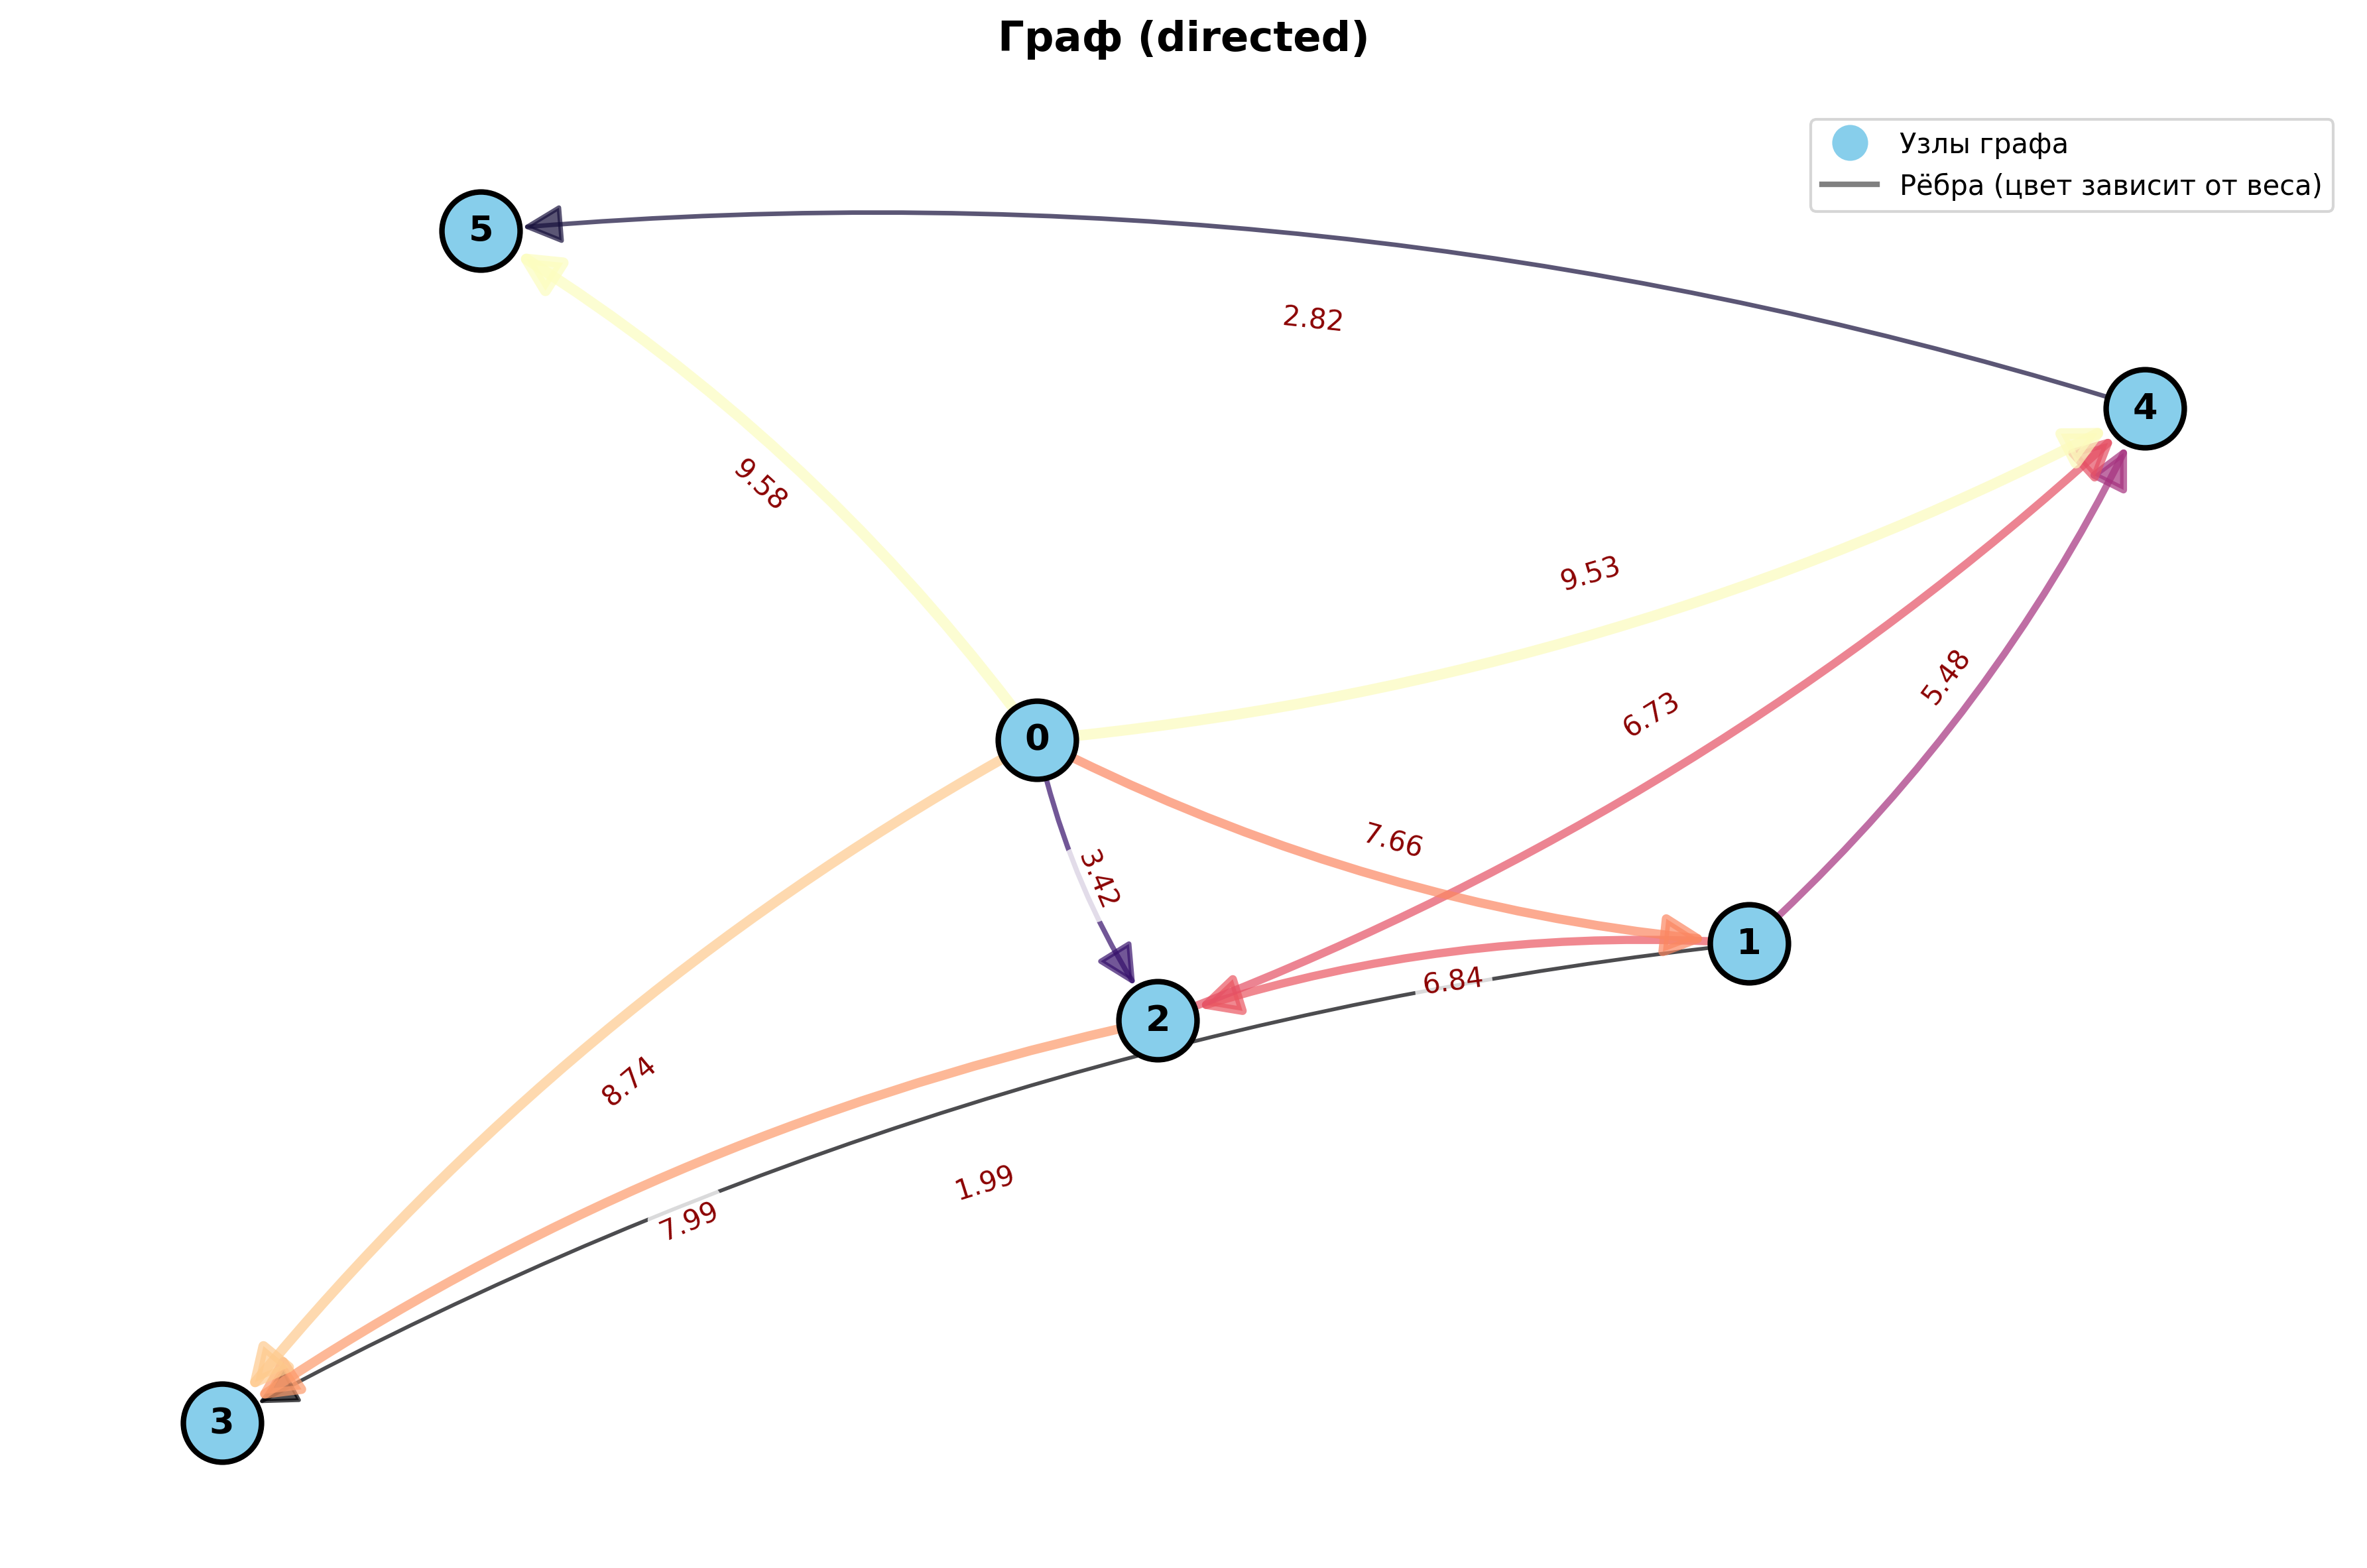

In [102]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/01_graph.png')

## Матрица смежности

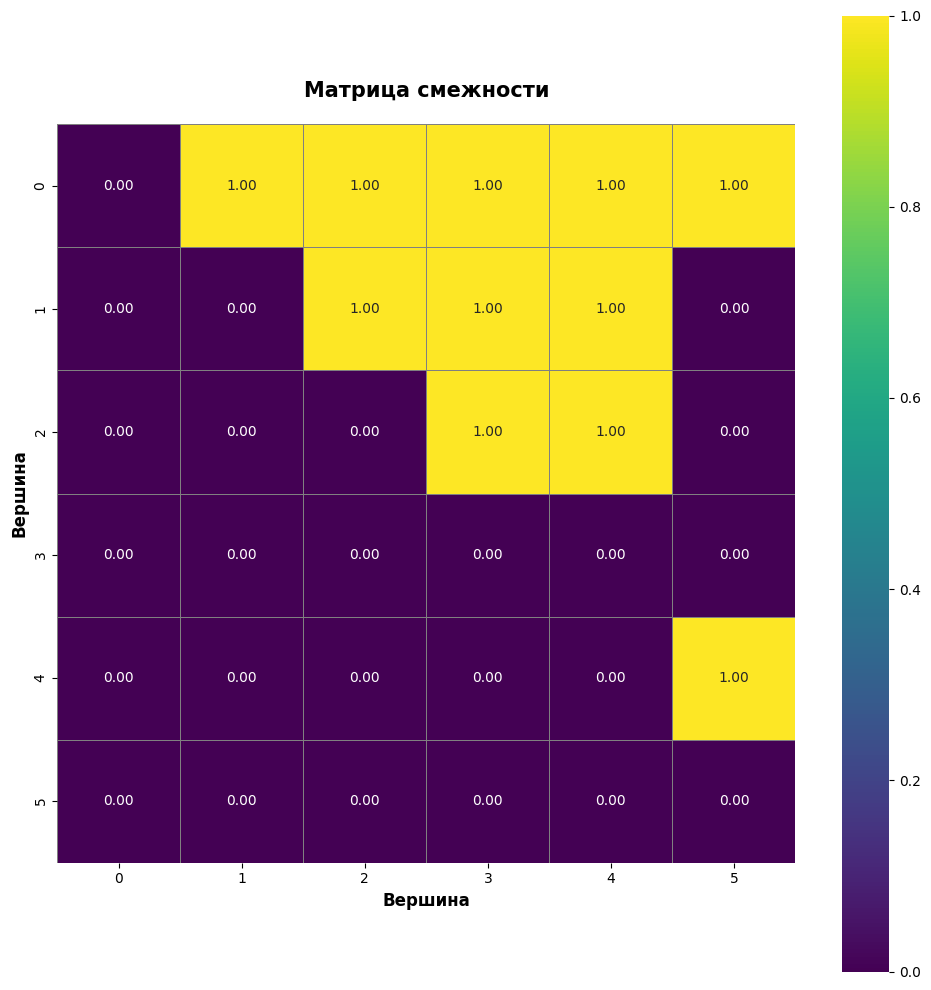

In [103]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/02_adjacency_matrix.png')

## Матрица весов

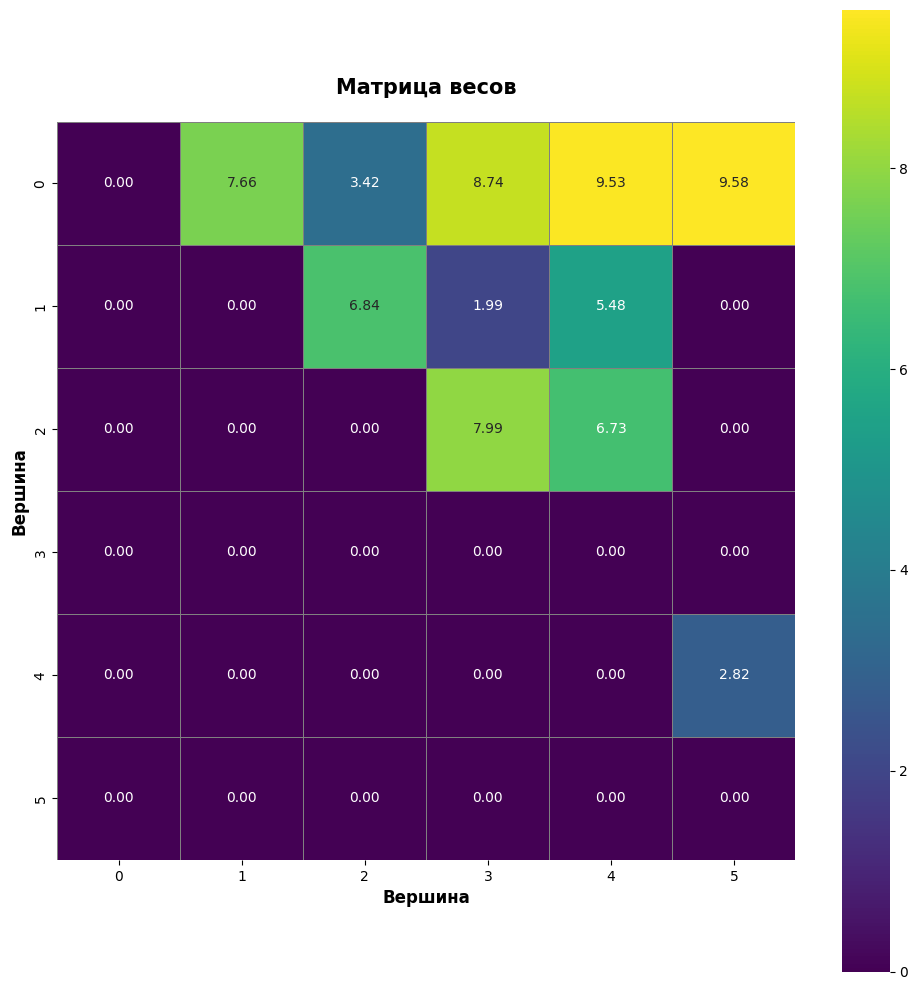

In [104]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/03_weight_matrix.png')

## Матрицы Шимбелла

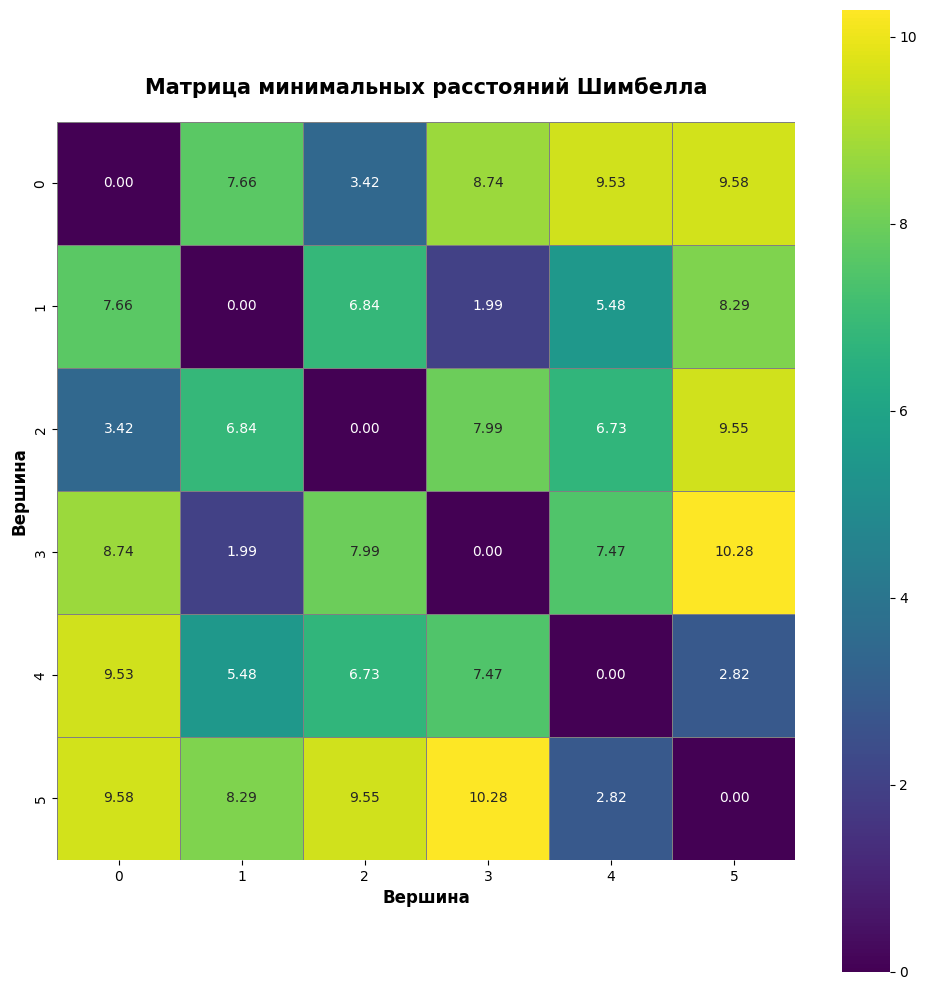

In [105]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/13_shimbell_min.png')

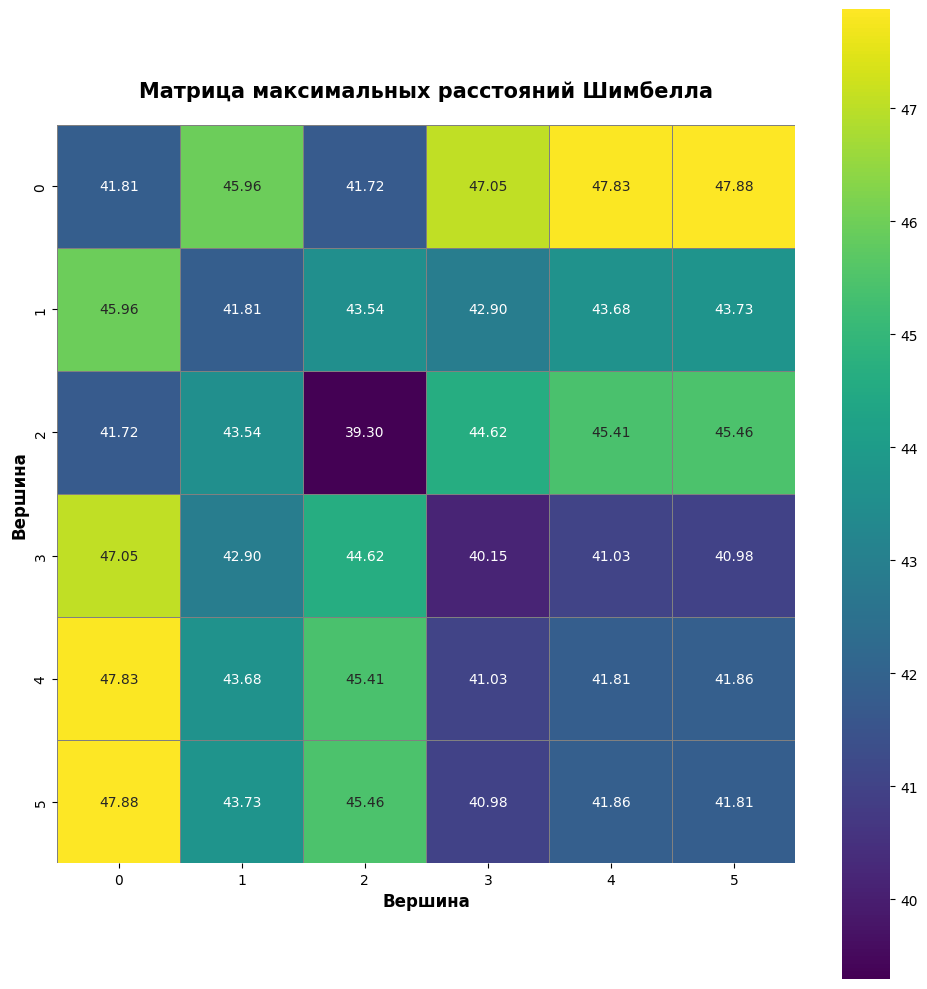

In [106]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/13_shimbell_max.png')

## Граф найденных путей

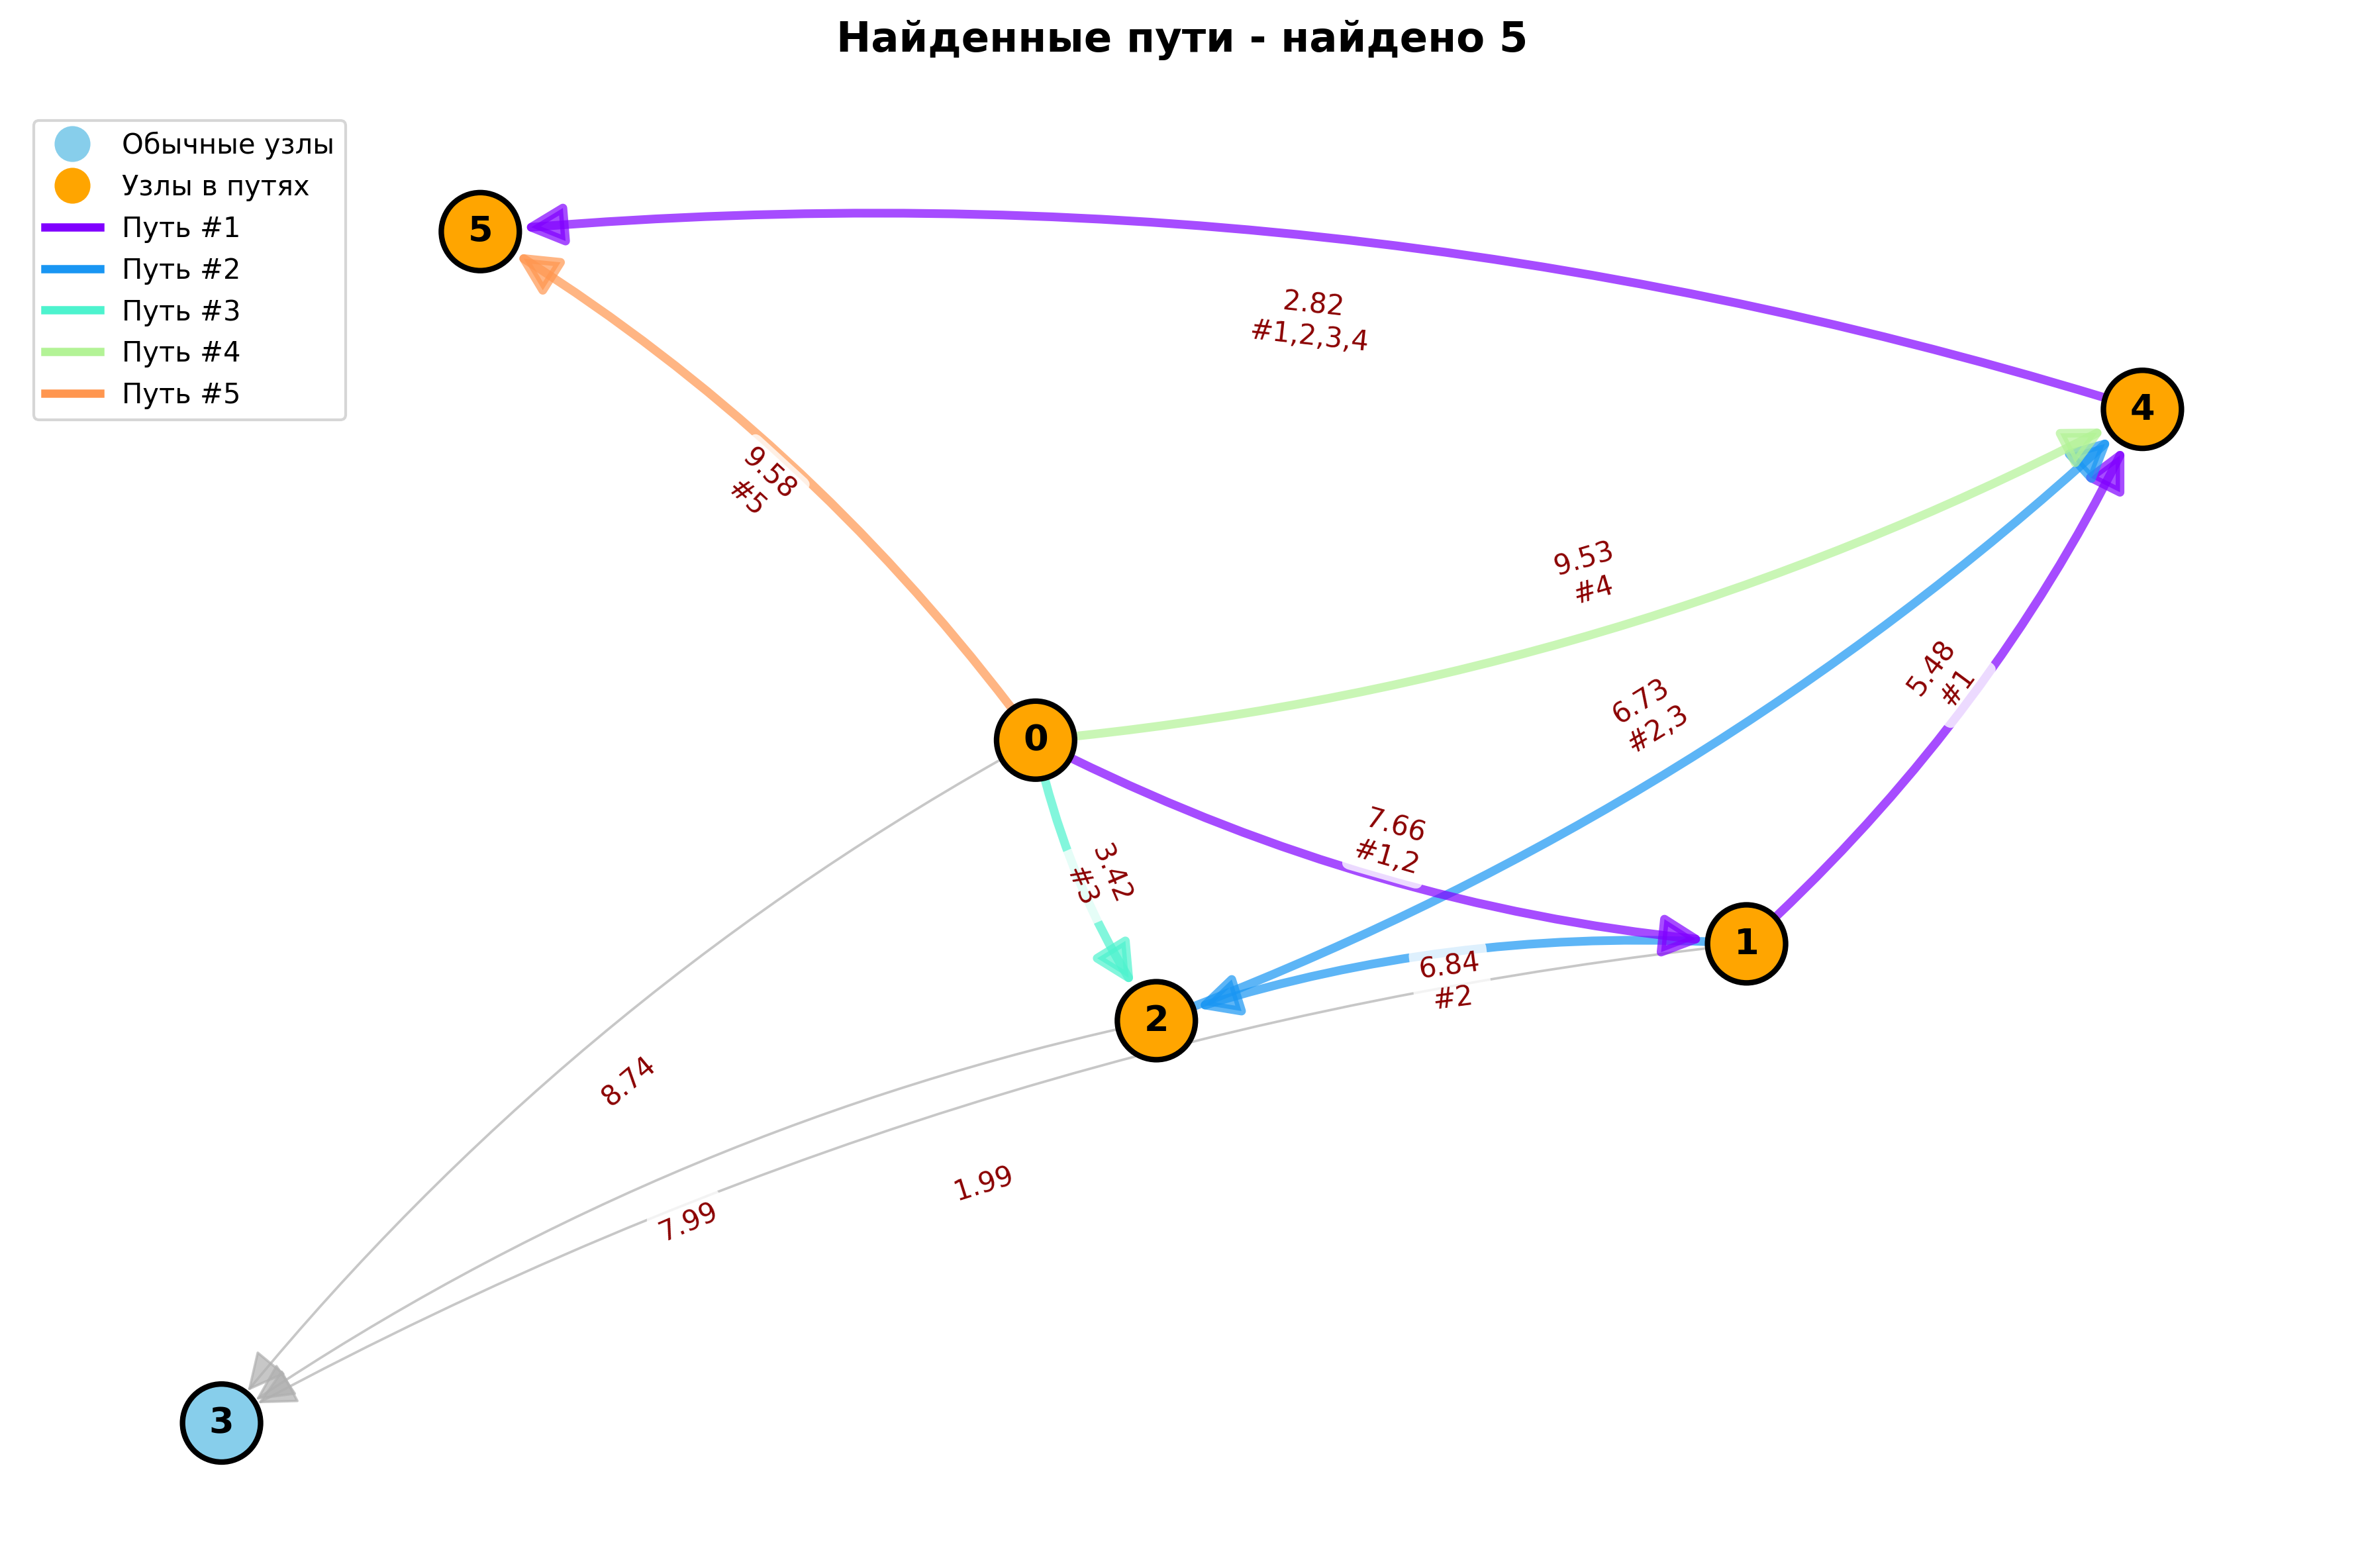

In [107]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/12_paths.png')

## Lab 3: Потоки


In [108]:
vertices = 6
edges = 11

run_cpp({
    '31': f'{vertices}\n{edges}\n',
    '32': f'0\n{vertices - 1}\n',
    '33': f'0\n{vertices - 1}\n1\n',
    '34': '',
    '35': '',
    '0': ''
})

True

## Визуализация сети потока

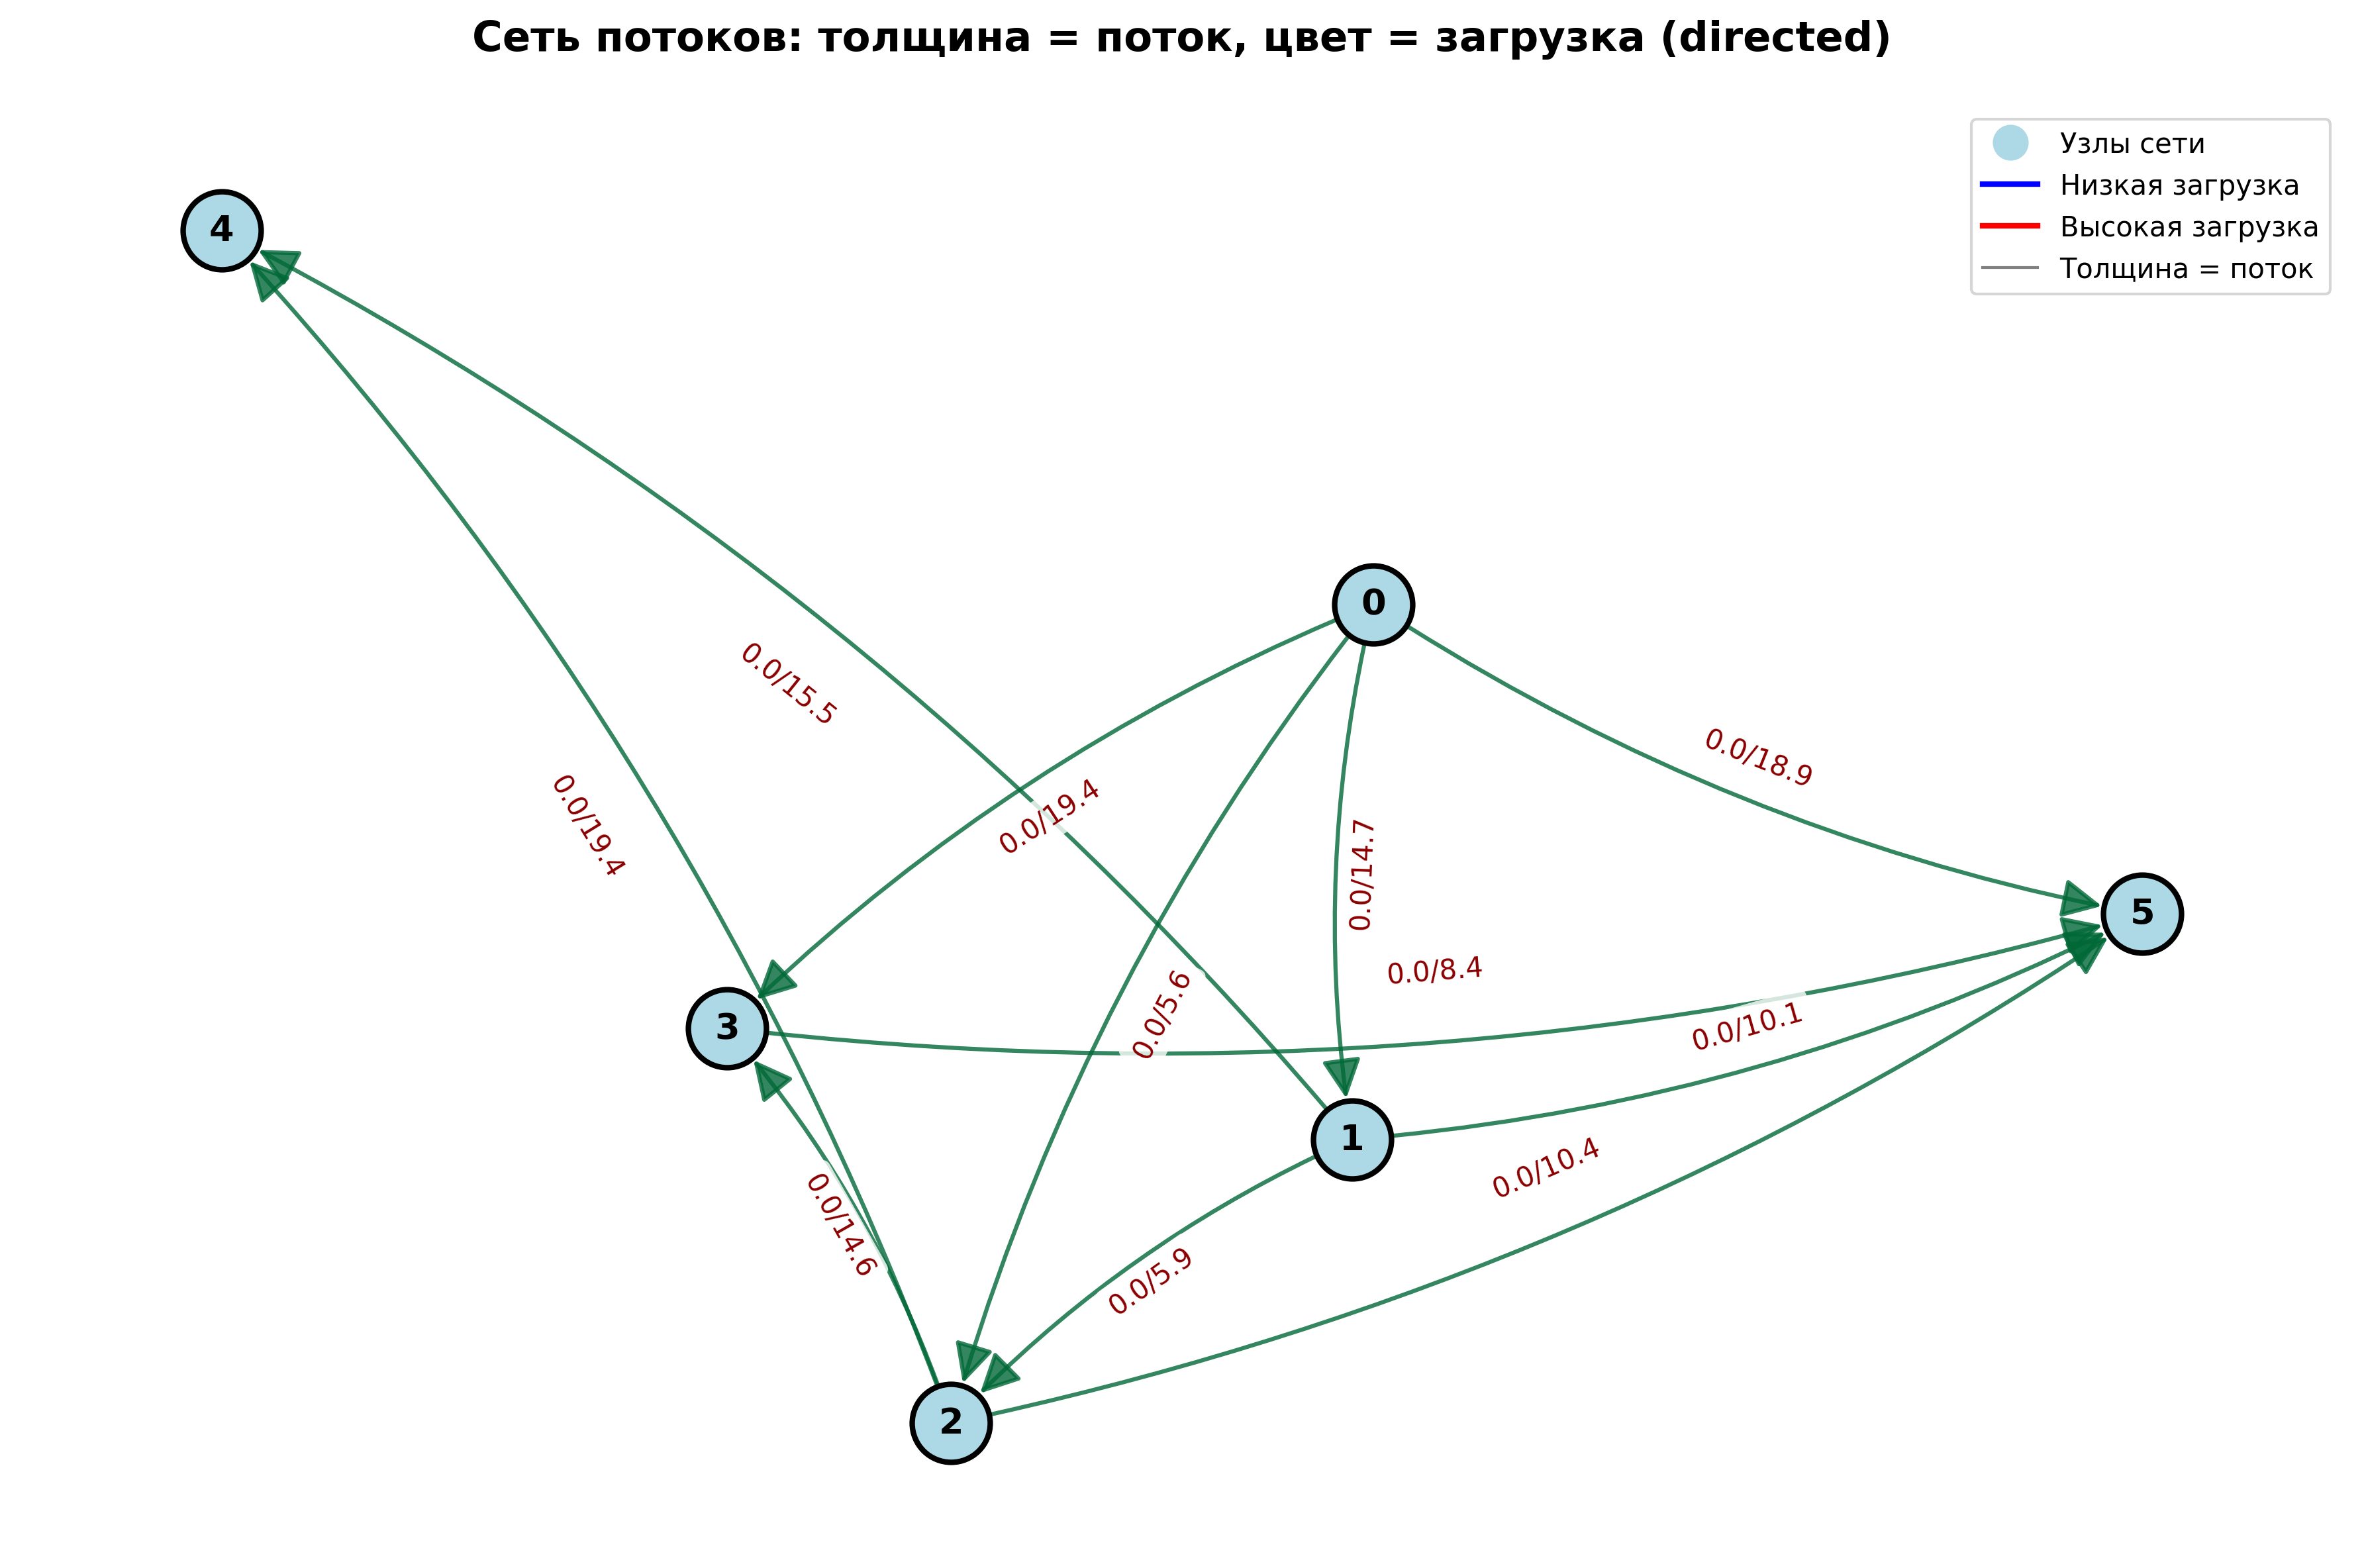

In [109]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/31_flow_network.png')

## Матрица пропускных способностей

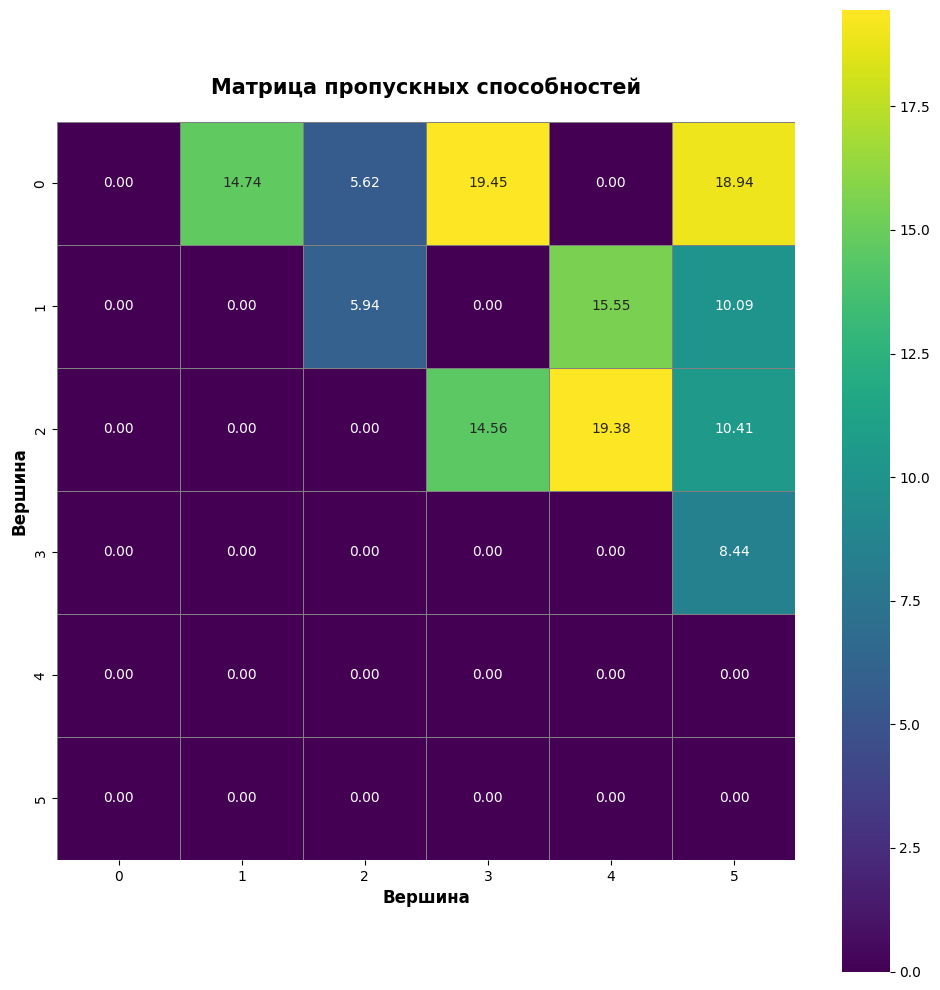

In [110]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/34_capacity_matrix.png')

## Матрица стоимостей

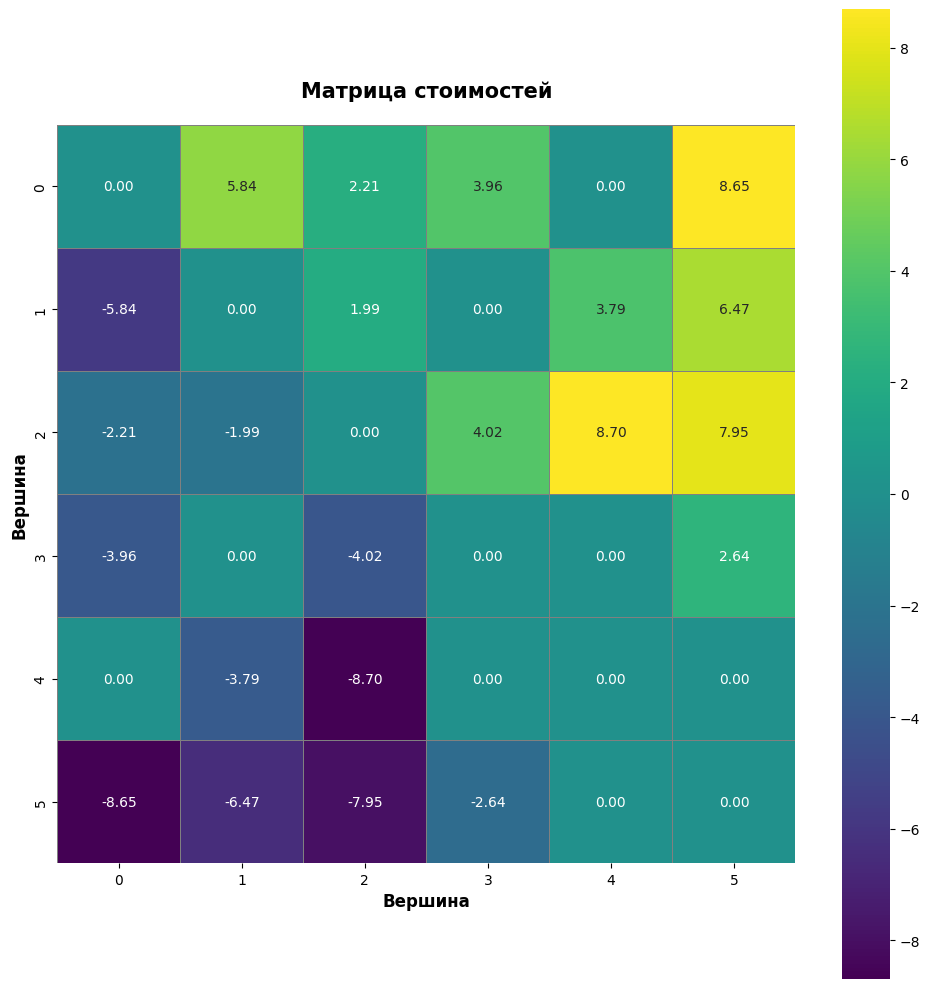

In [111]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/35_cost_matrix.png')

## Визуализация максимального потока (PNG и GIF)

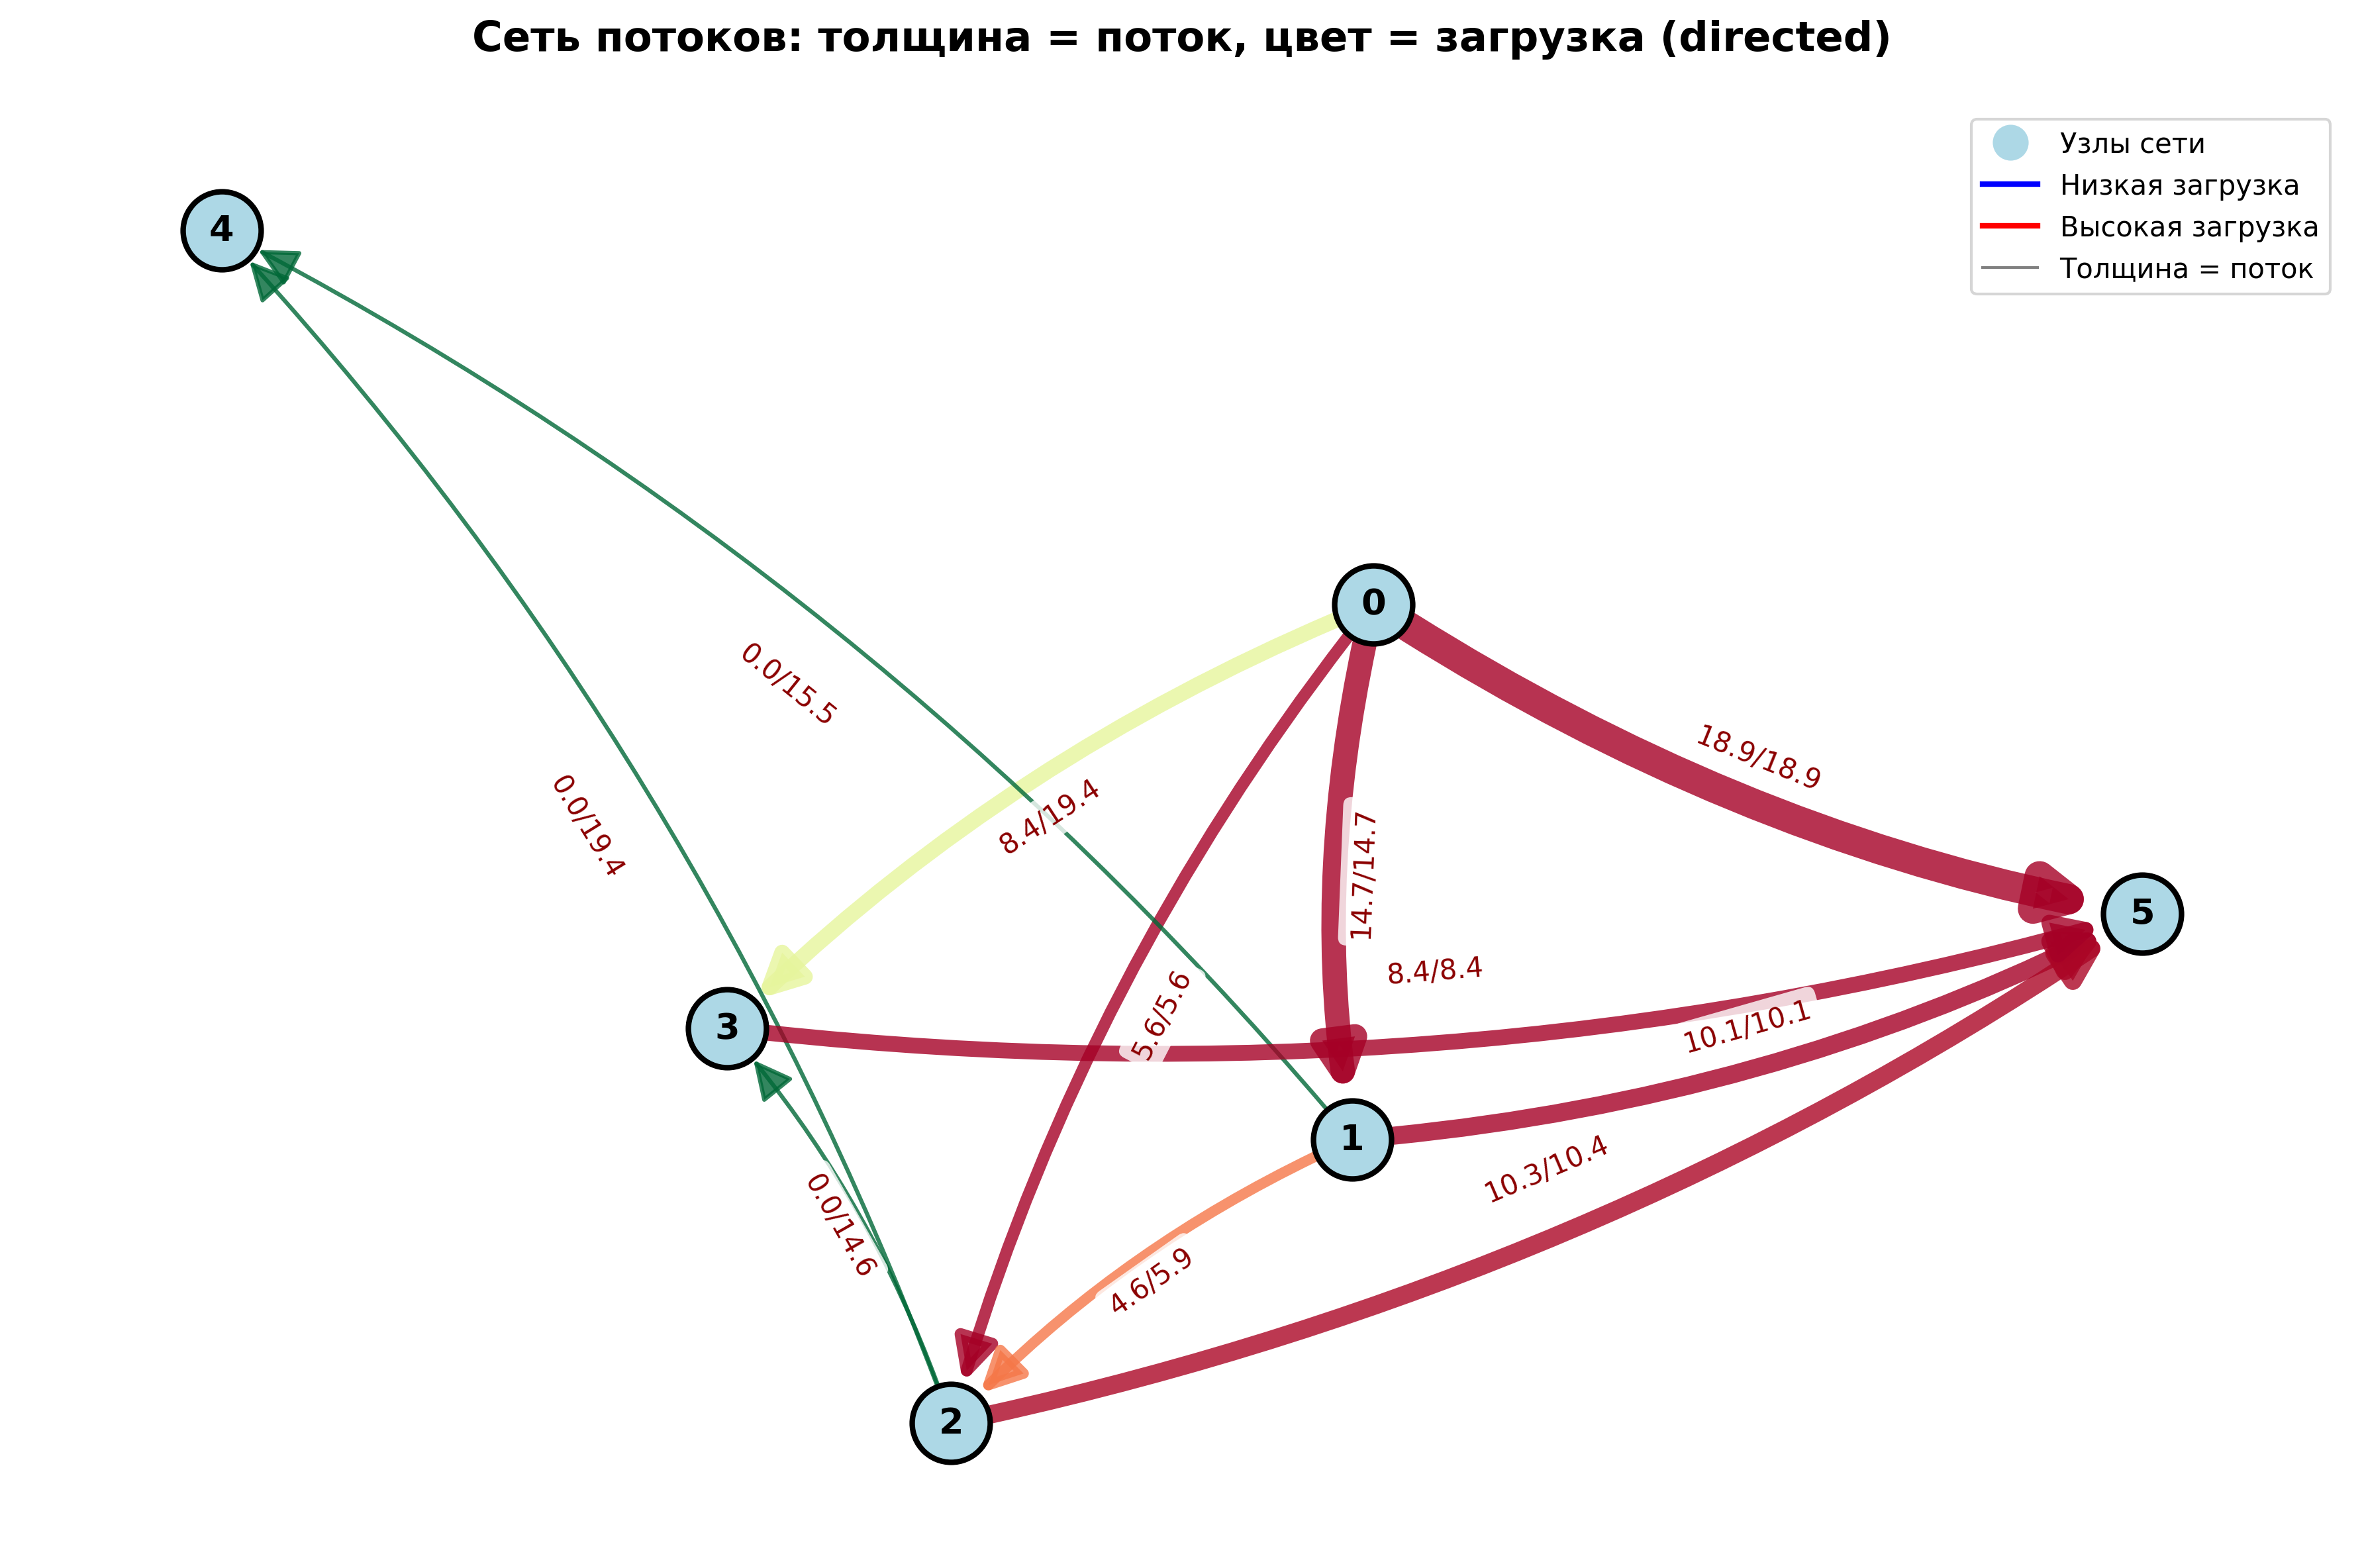

In [112]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/32_max_flow.png')

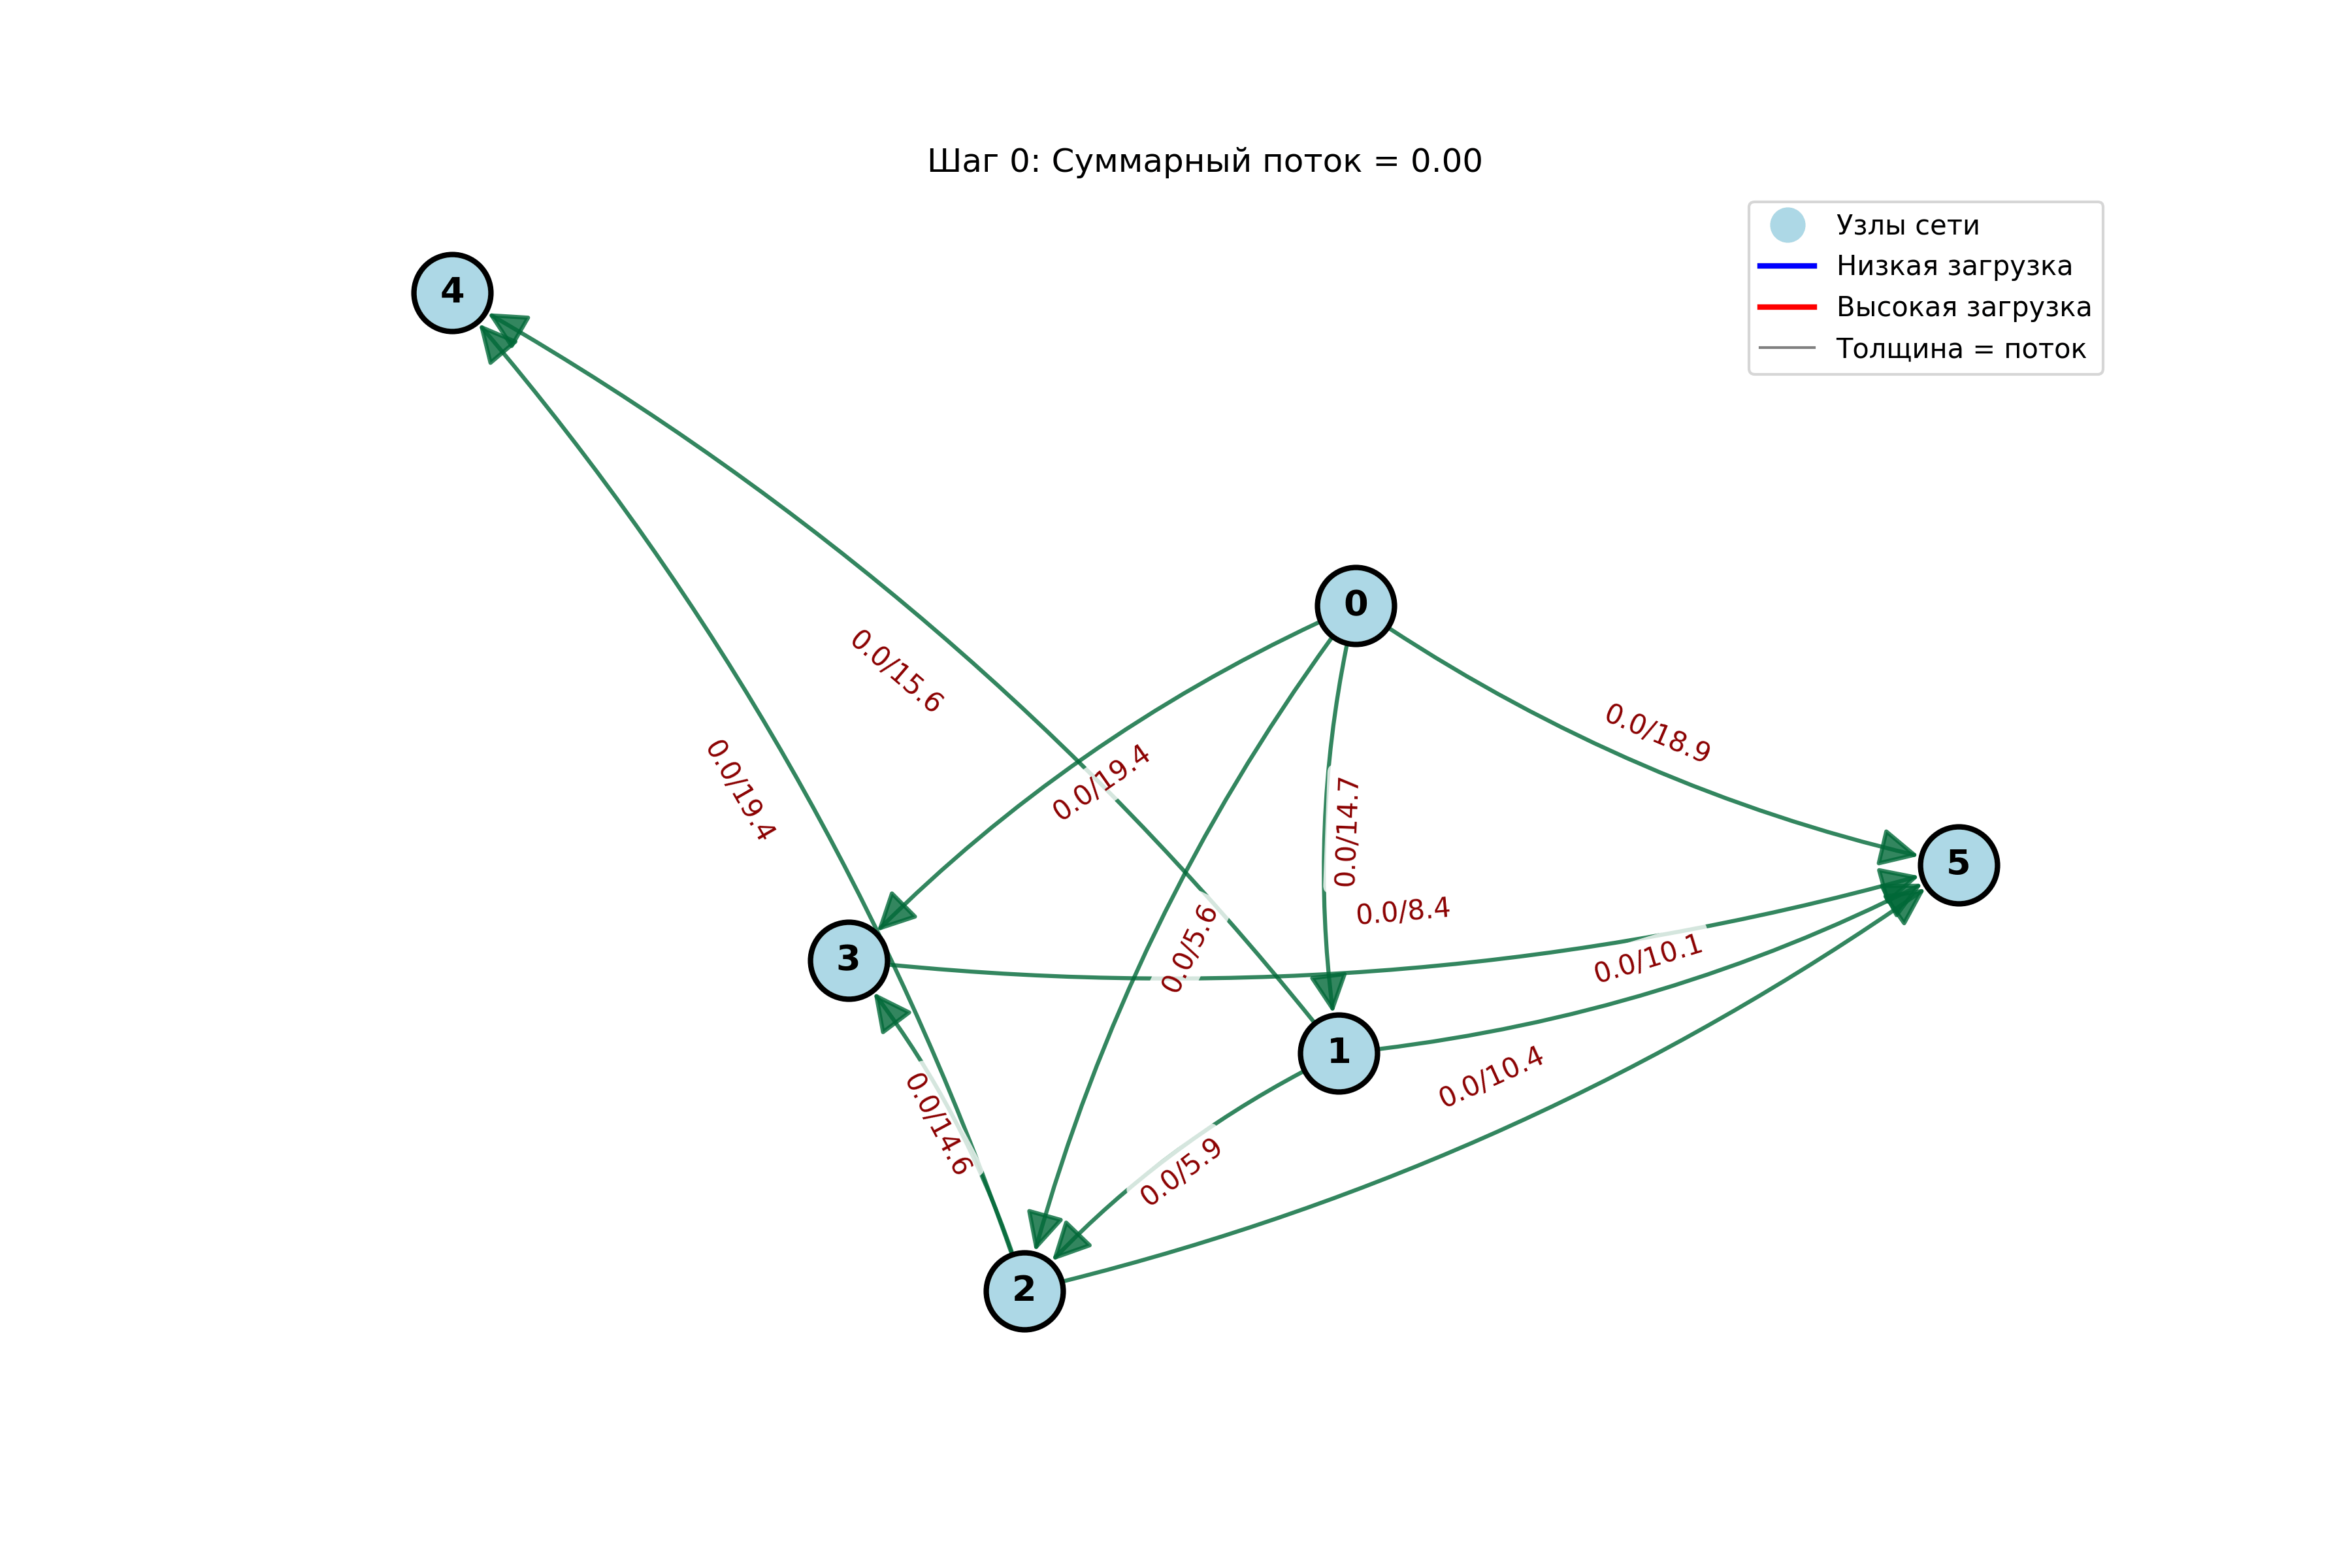

In [113]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/gif/37_flow_animation.gif')

## Визуализация потока минимальной стоимости

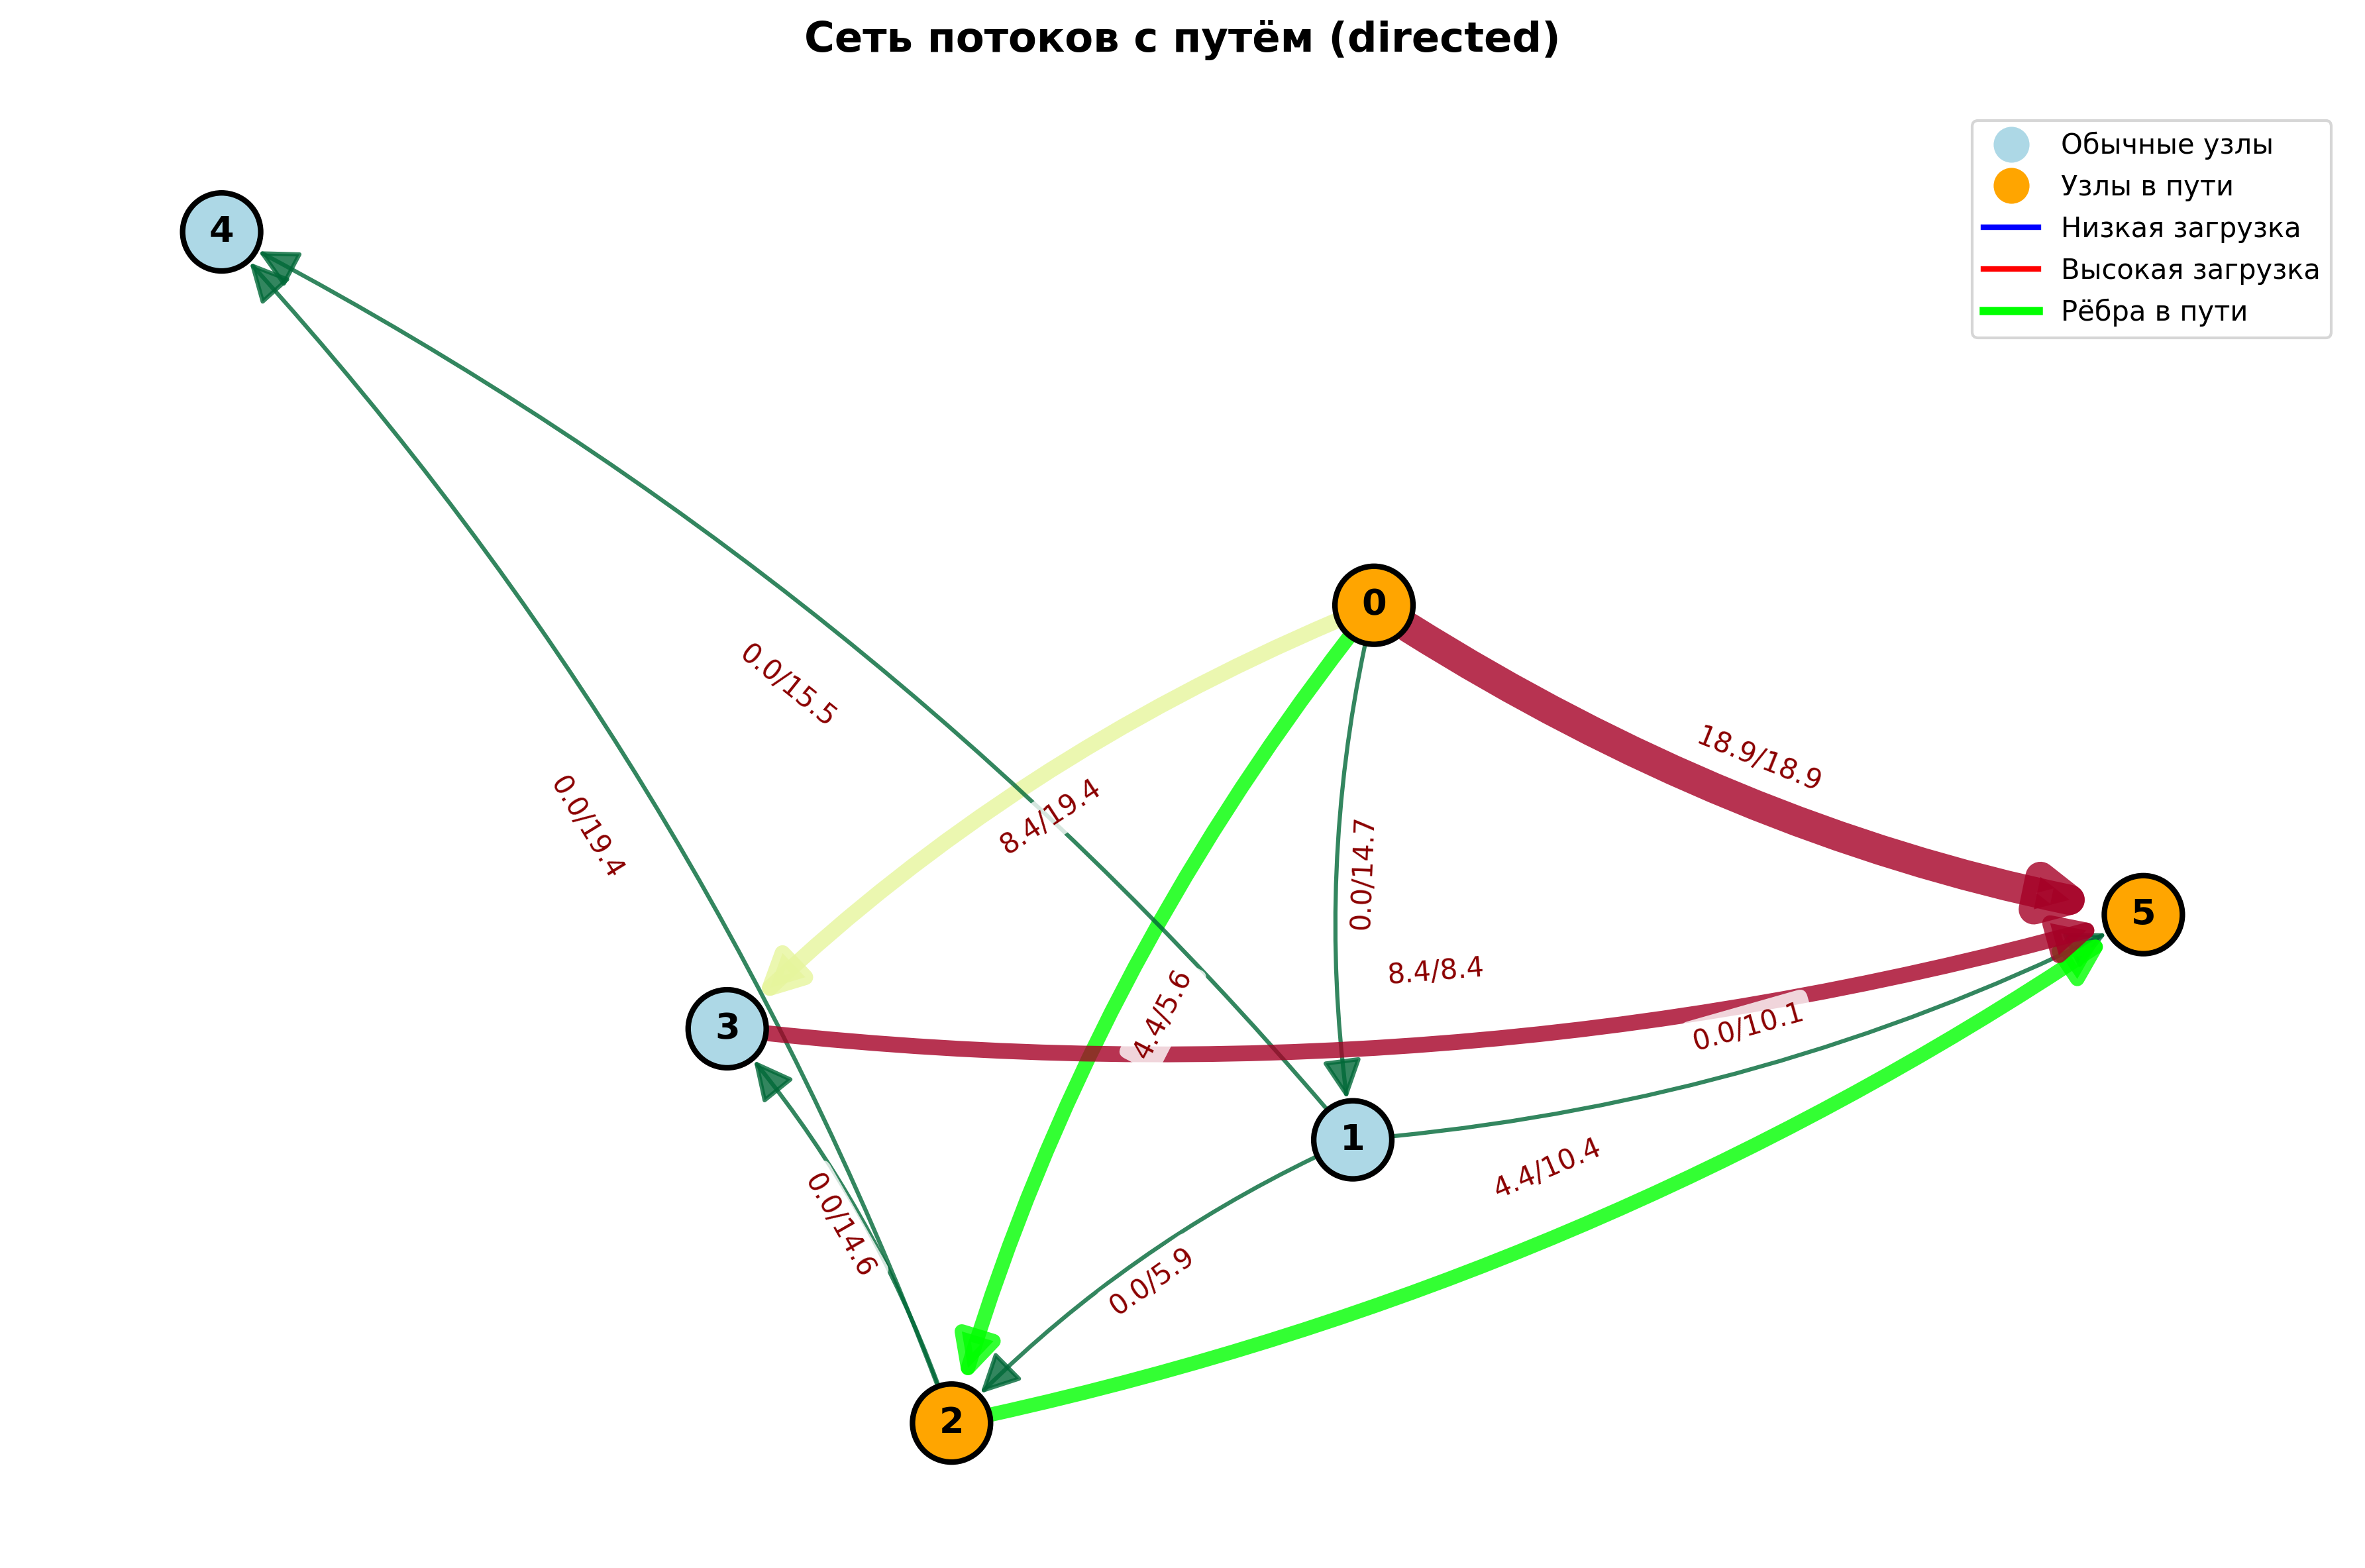

In [114]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/33_min_cost_flow_path.png')

## Lab 4: Остовы и комбинорика над графами

In [115]:
directed = 1
vertices = 6
edges = 11

run_cpp({
    '1' : f'{directed}\n{vertices}\n{edges}\n',
    '41': '',
    '42': '',
    '43': '',
    '44': '',
    '45': '',
    '46': '',
    '0': ''
})

True

## Максимальное независимое множество вершин/ребер

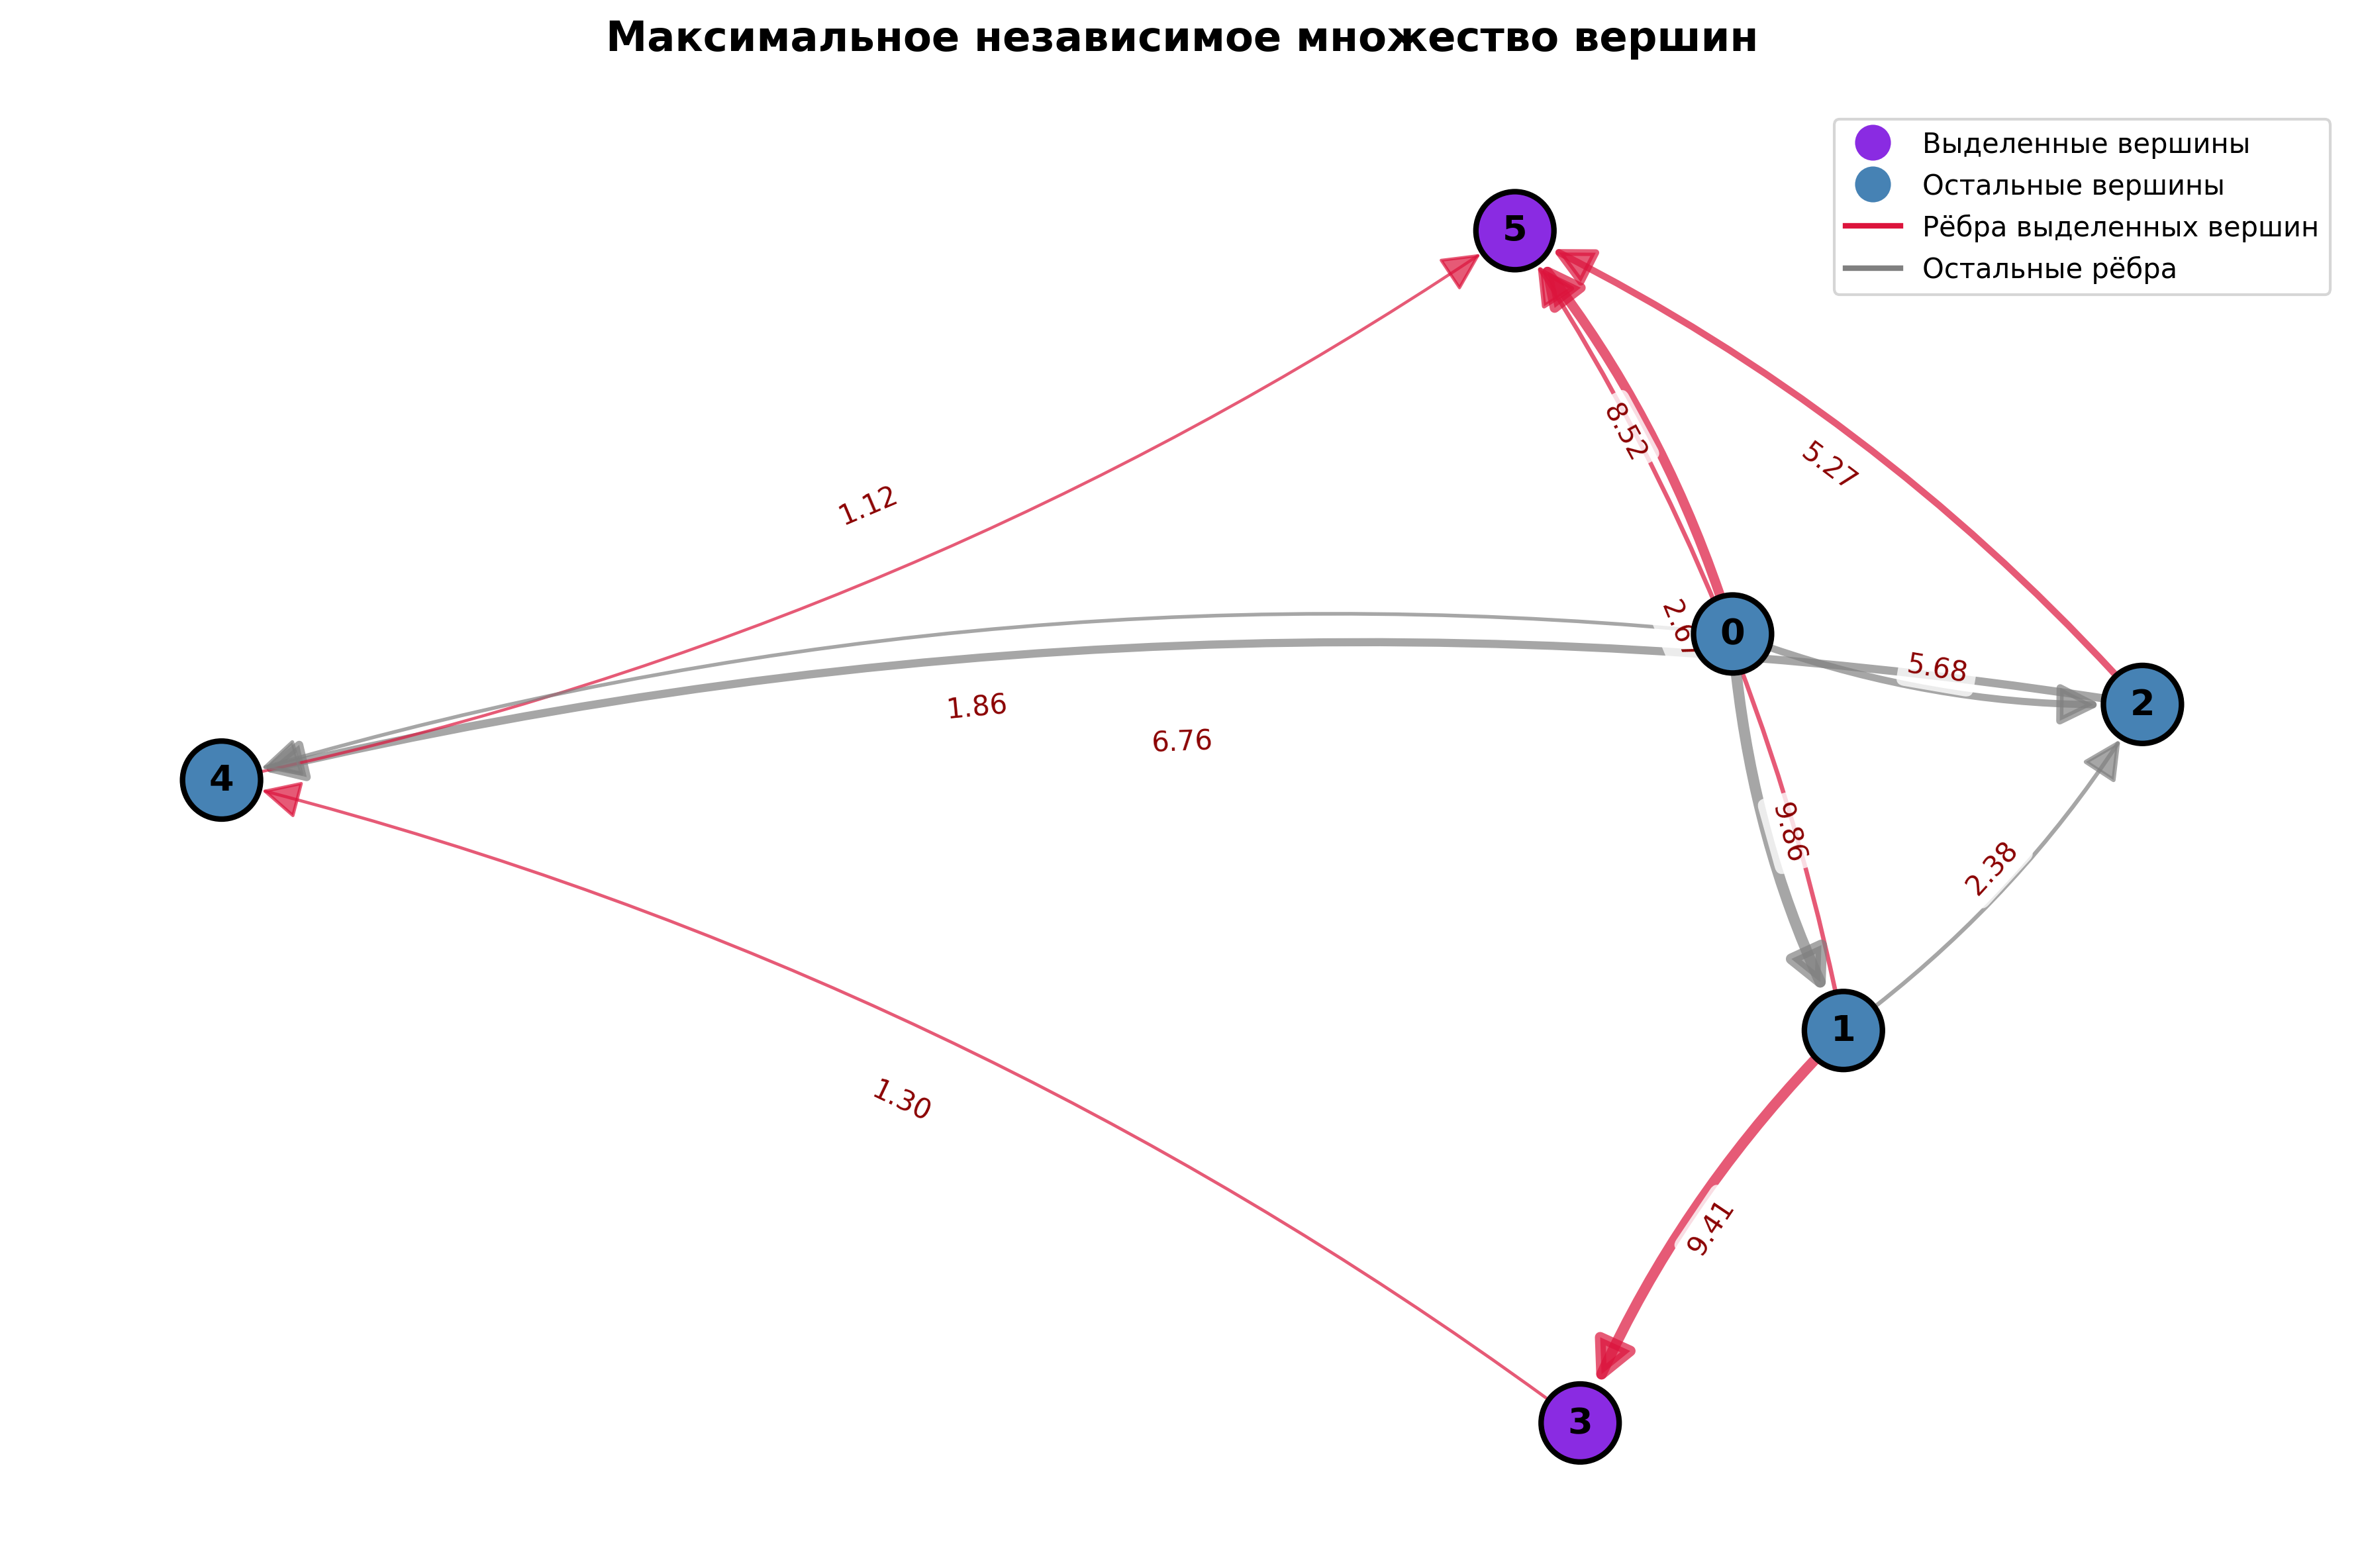

In [116]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/42_independent_set.png')

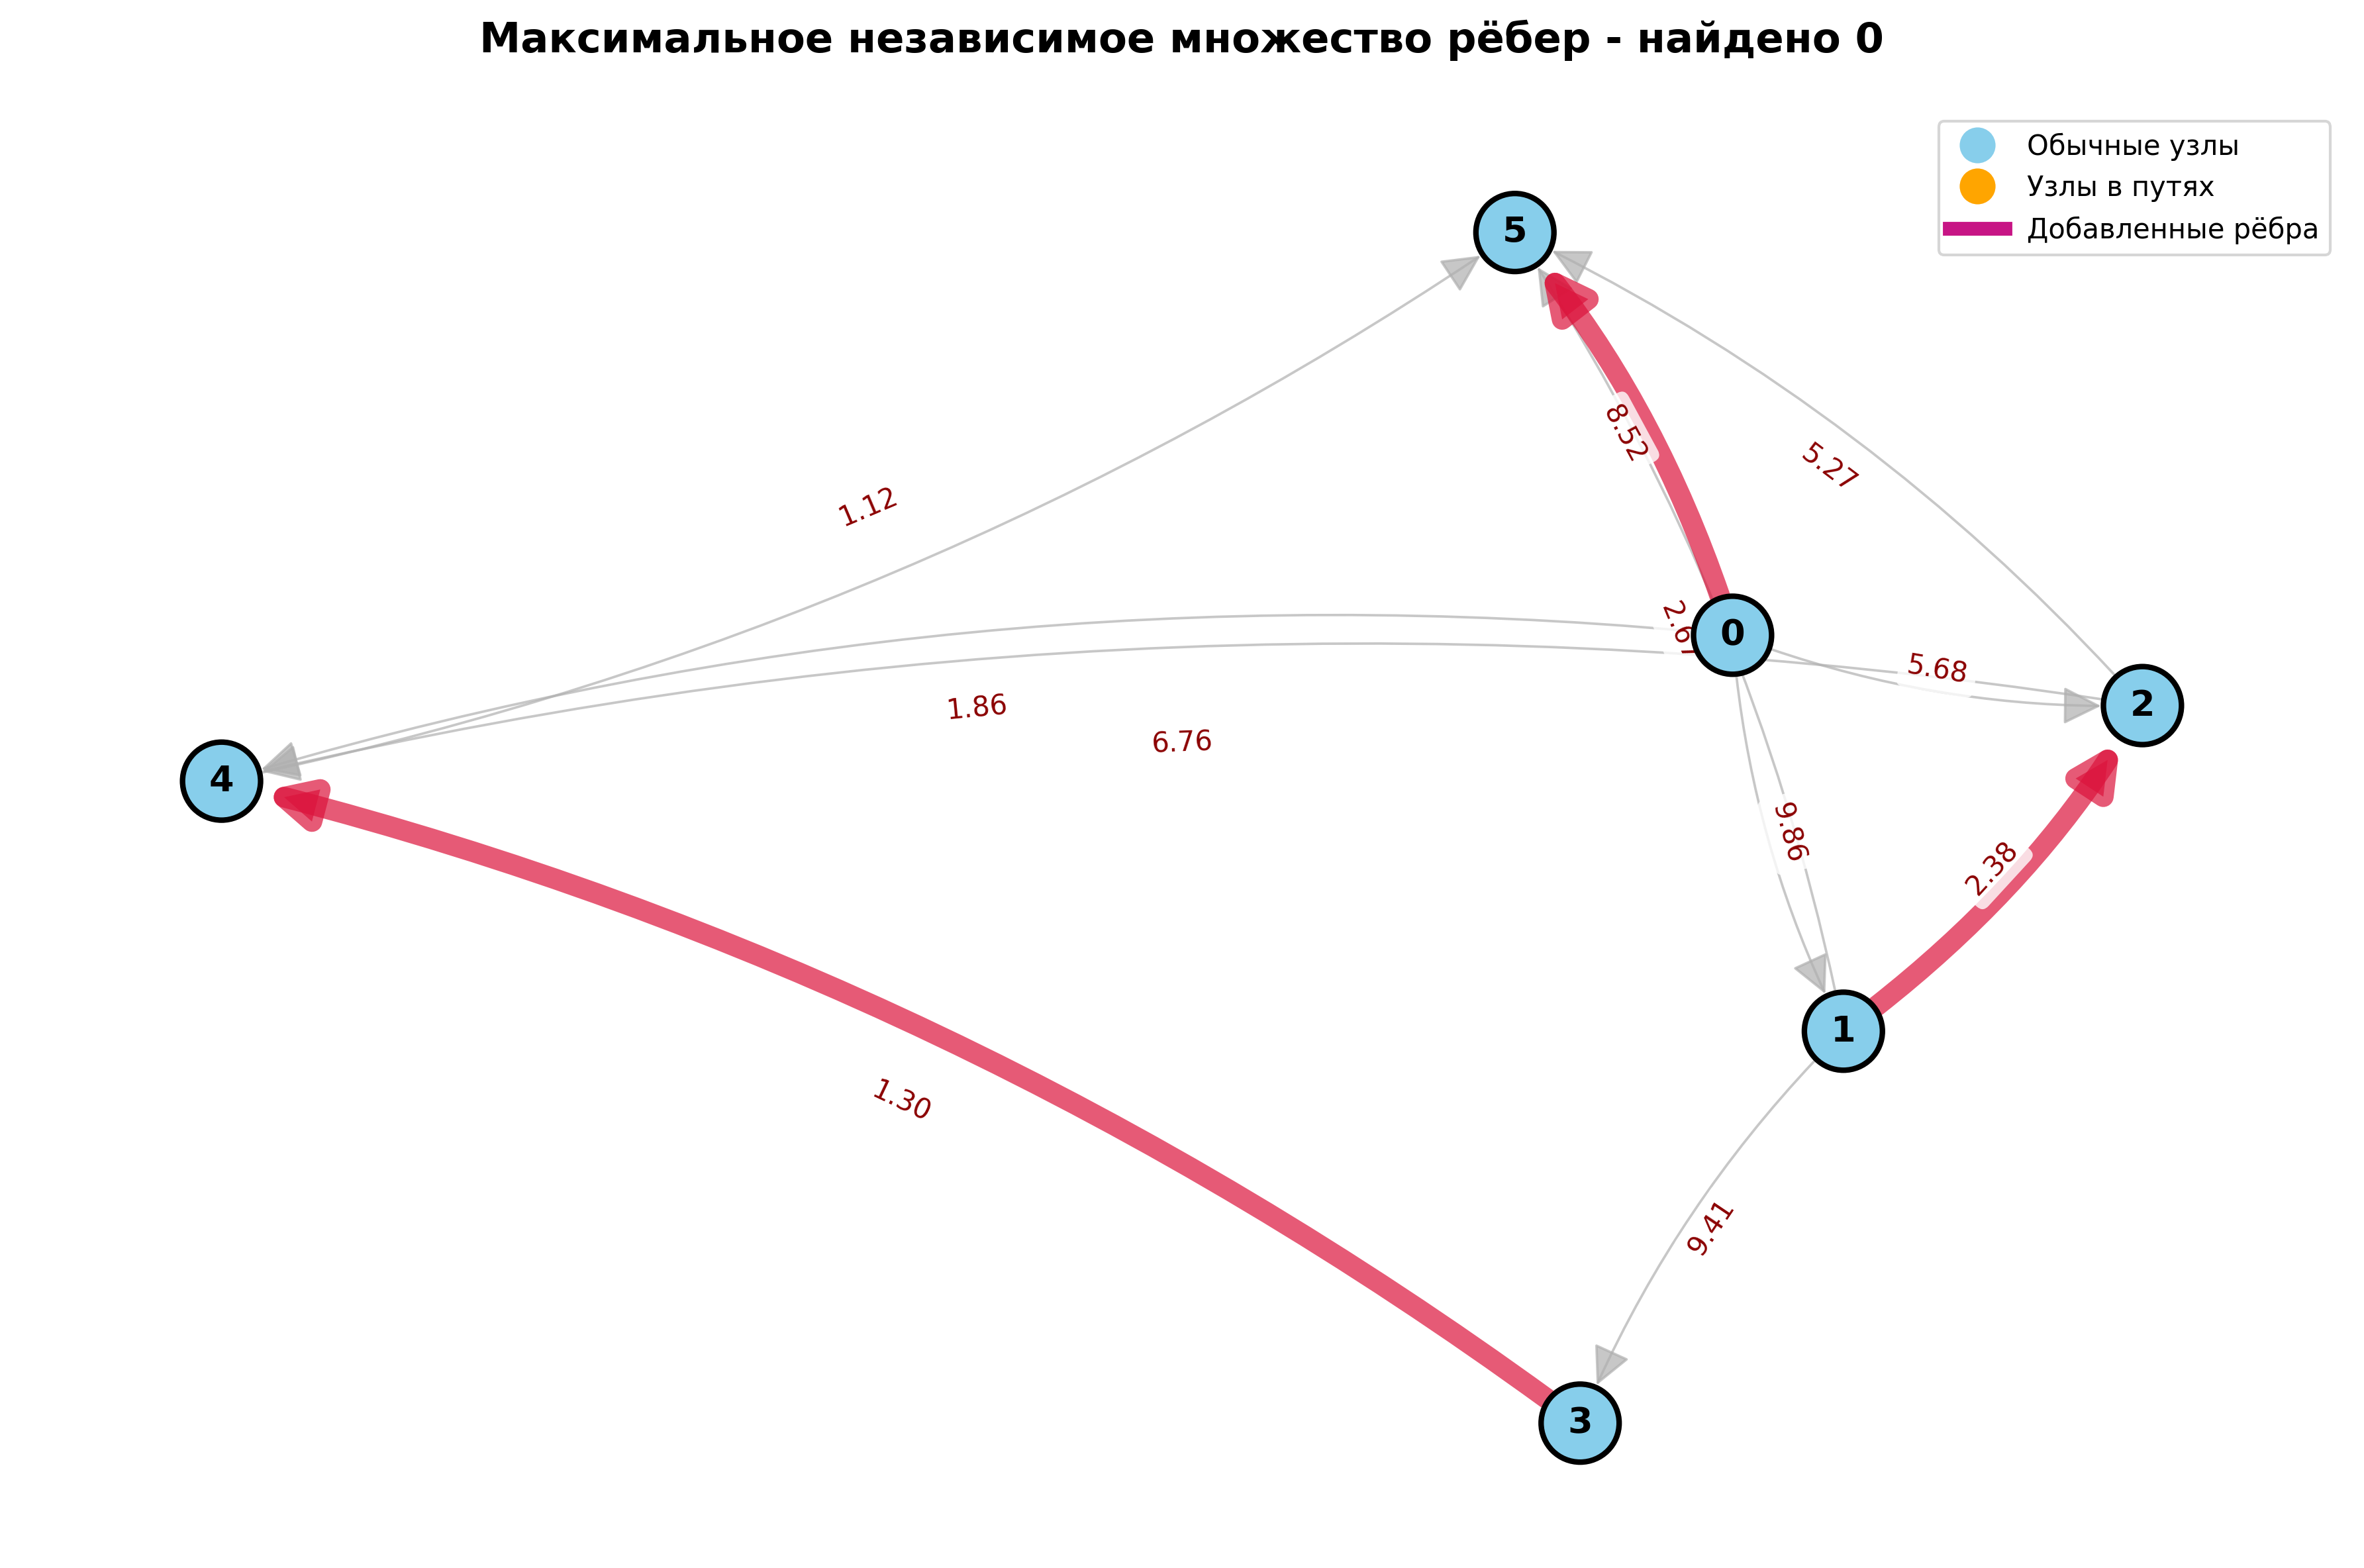

In [117]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/43_independent_edges.png')

## Минимальное вершиное/ребернок покрытие

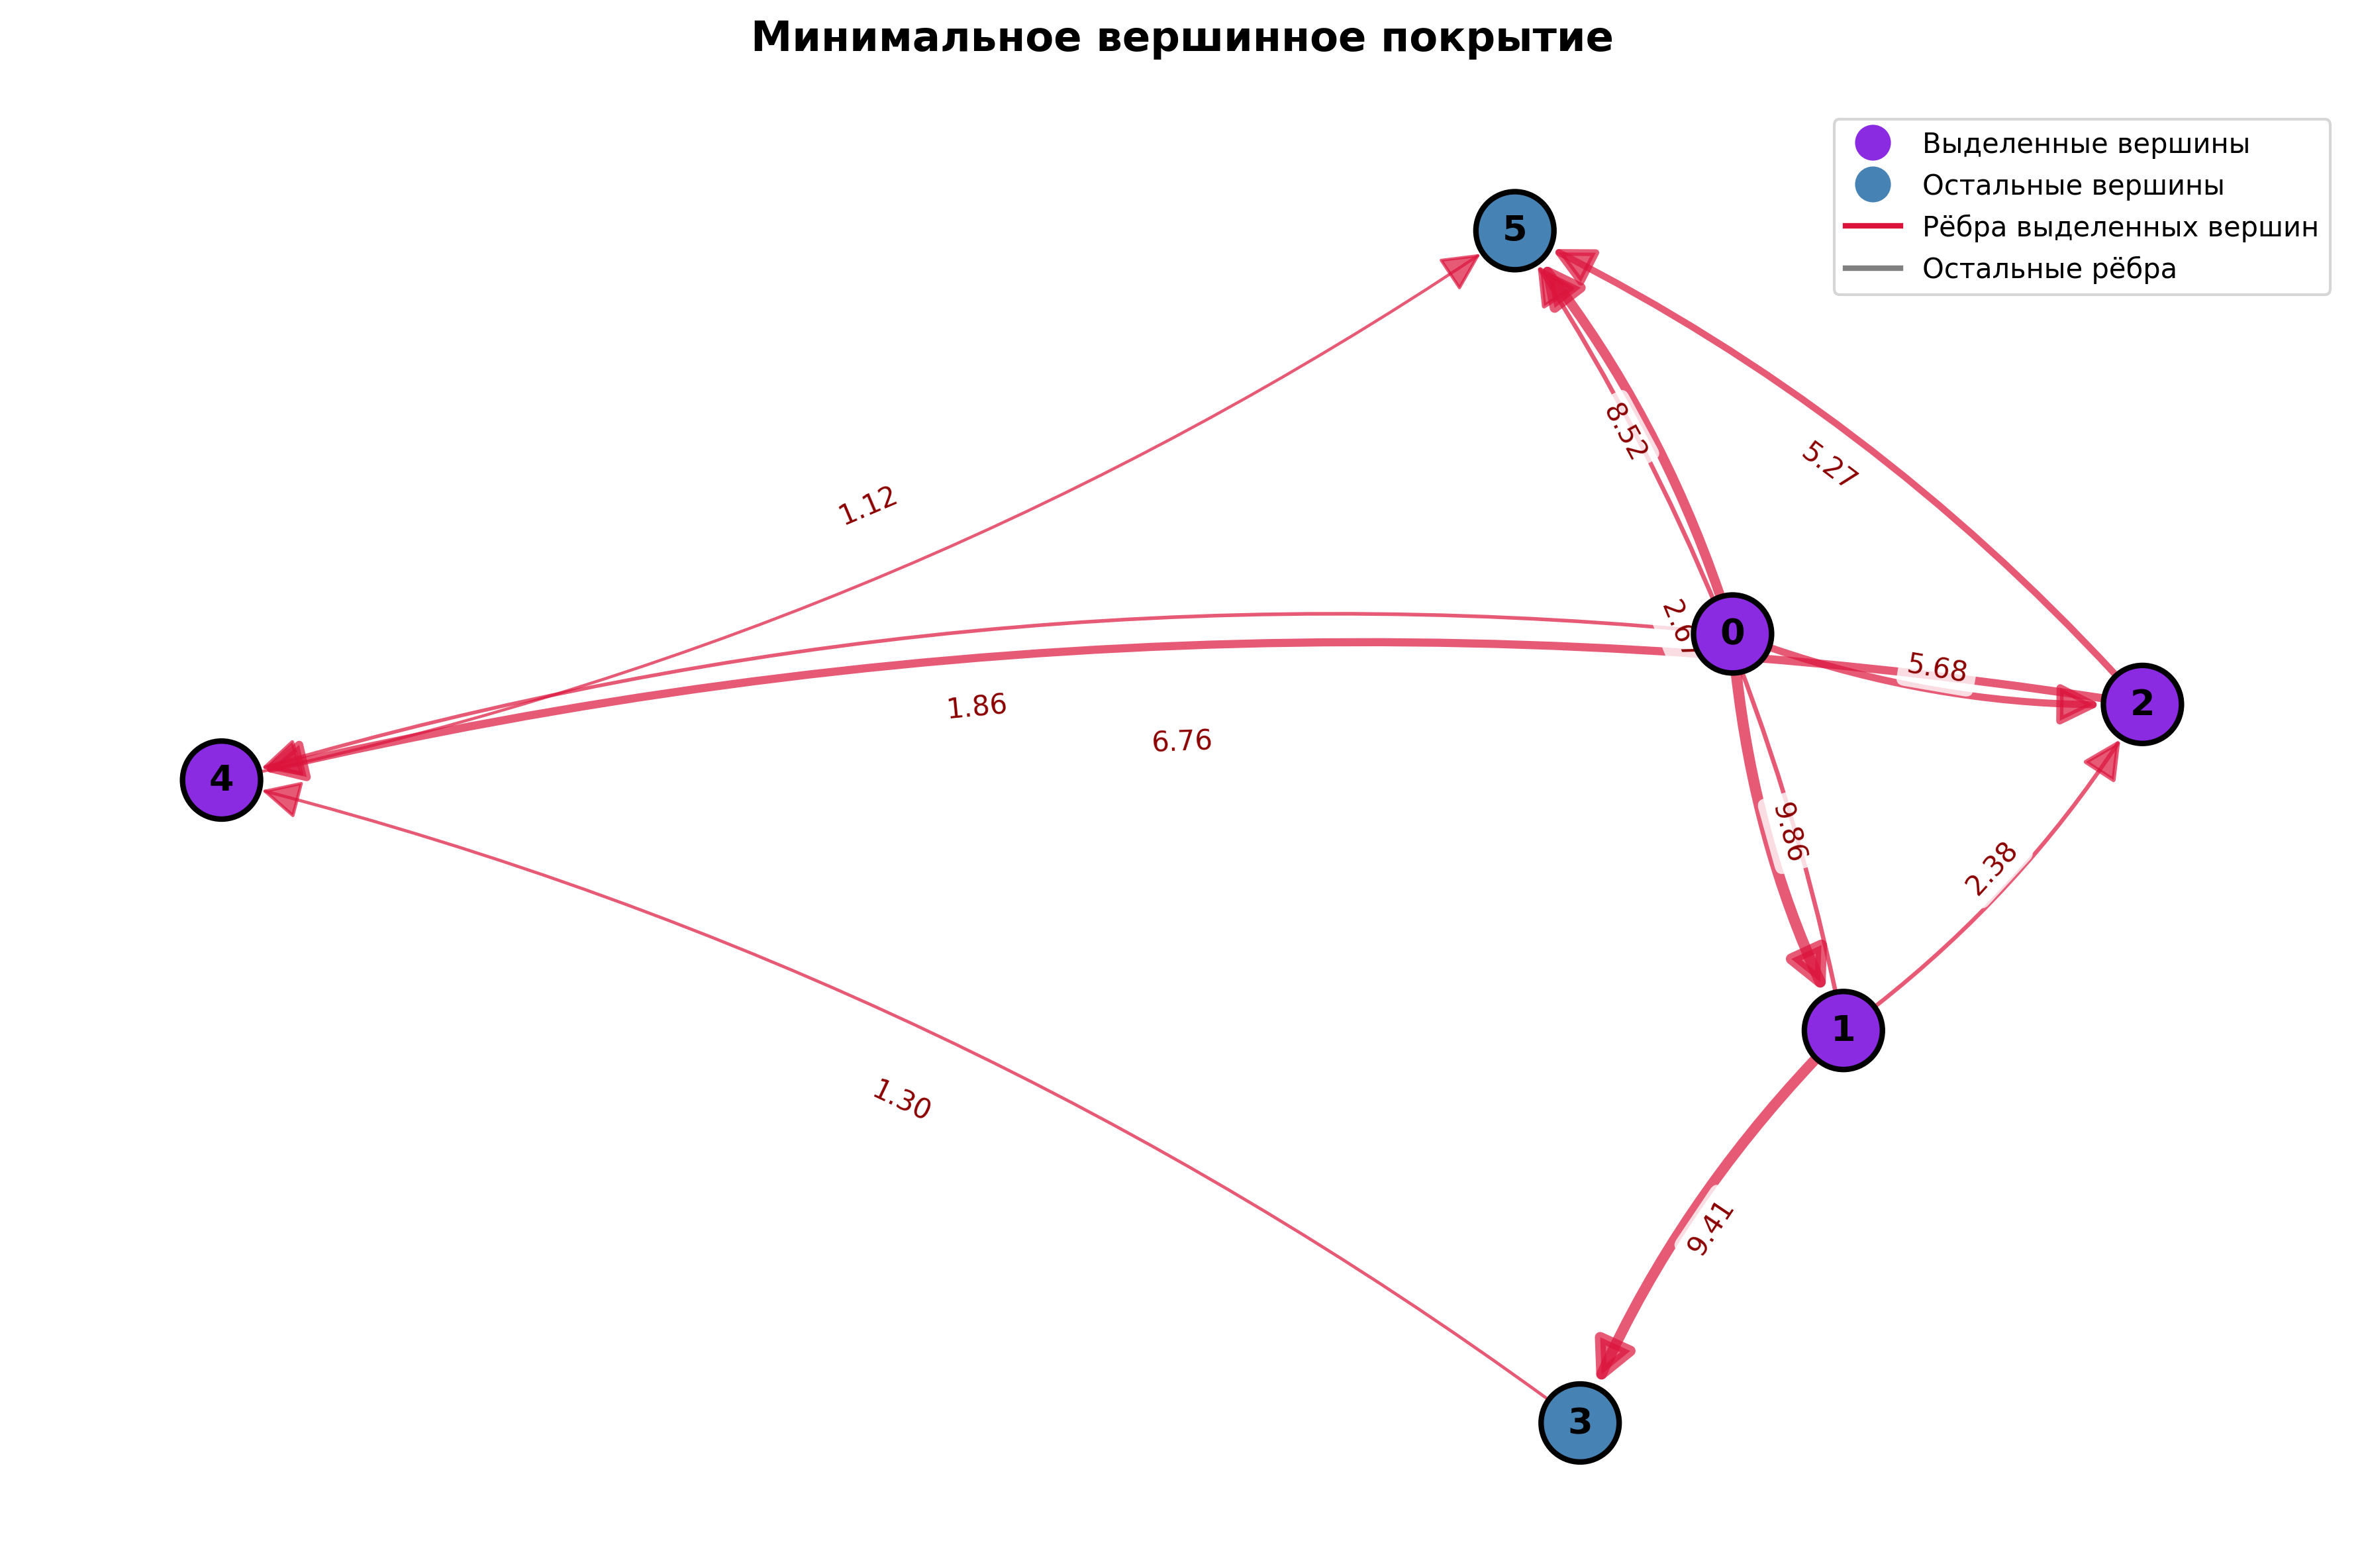

In [118]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/44_vertex_cover.png')

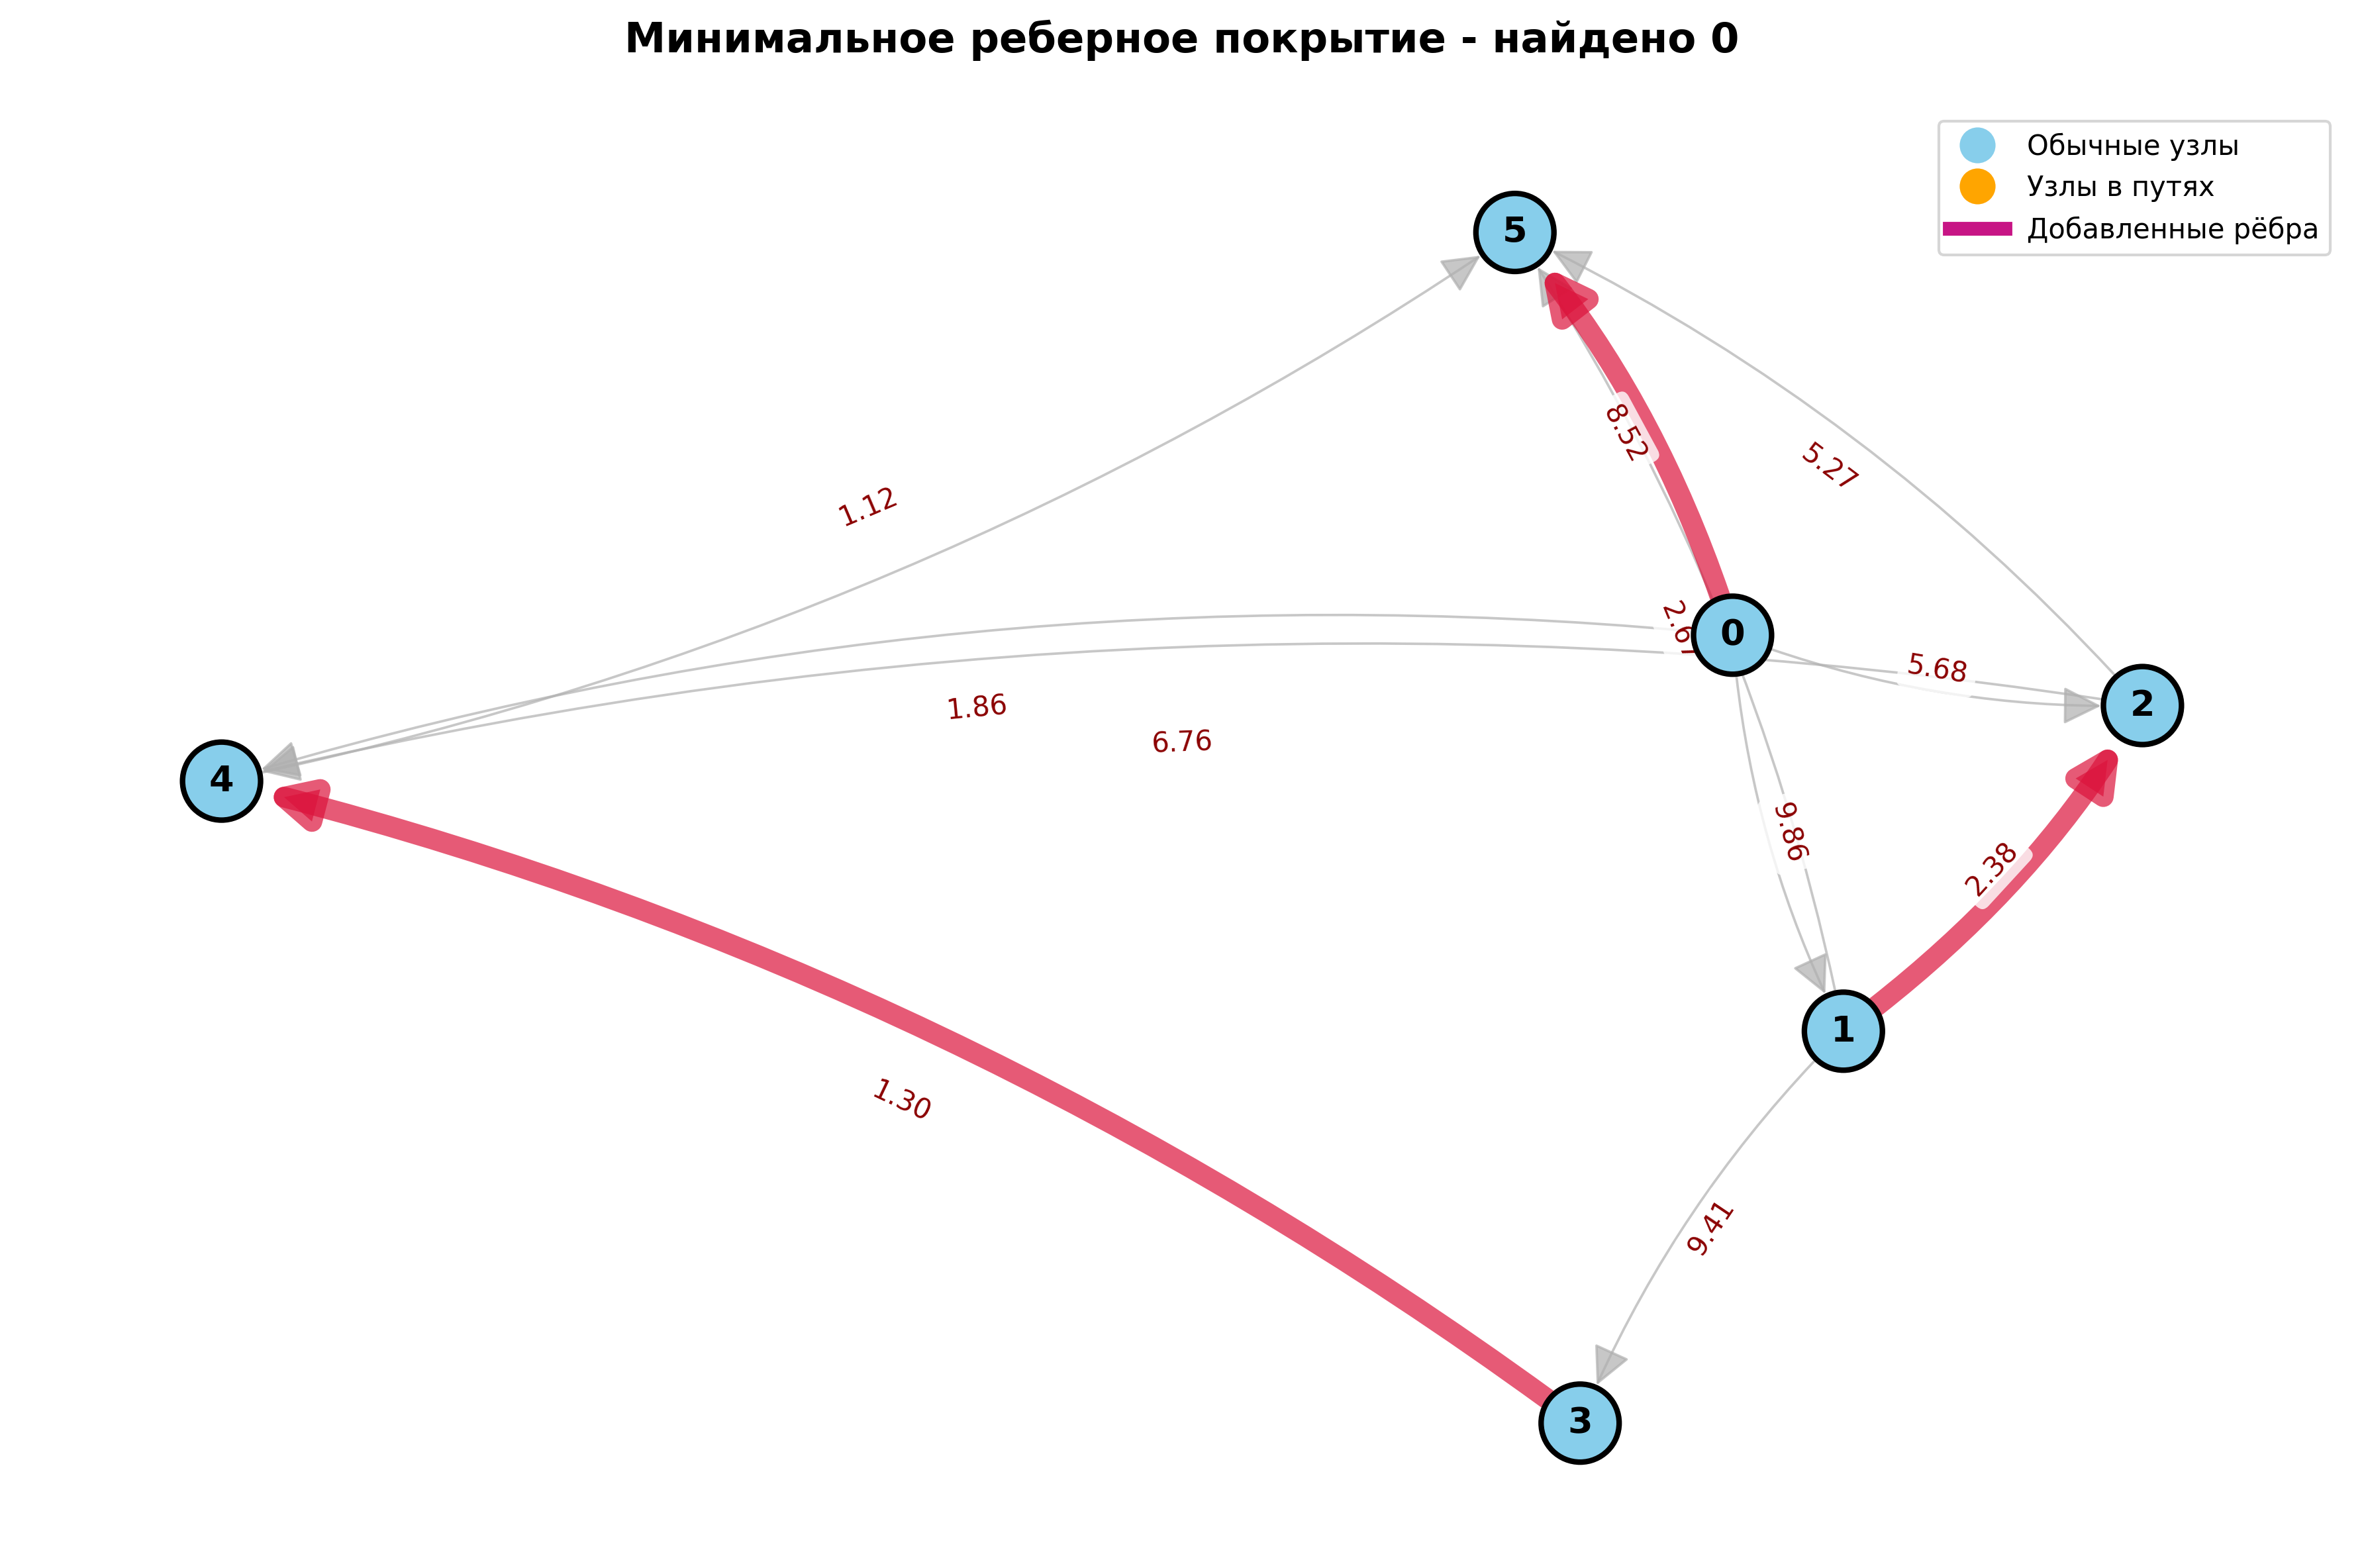

In [119]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/45_edge_cover.png')

## Минимальная покраска графа

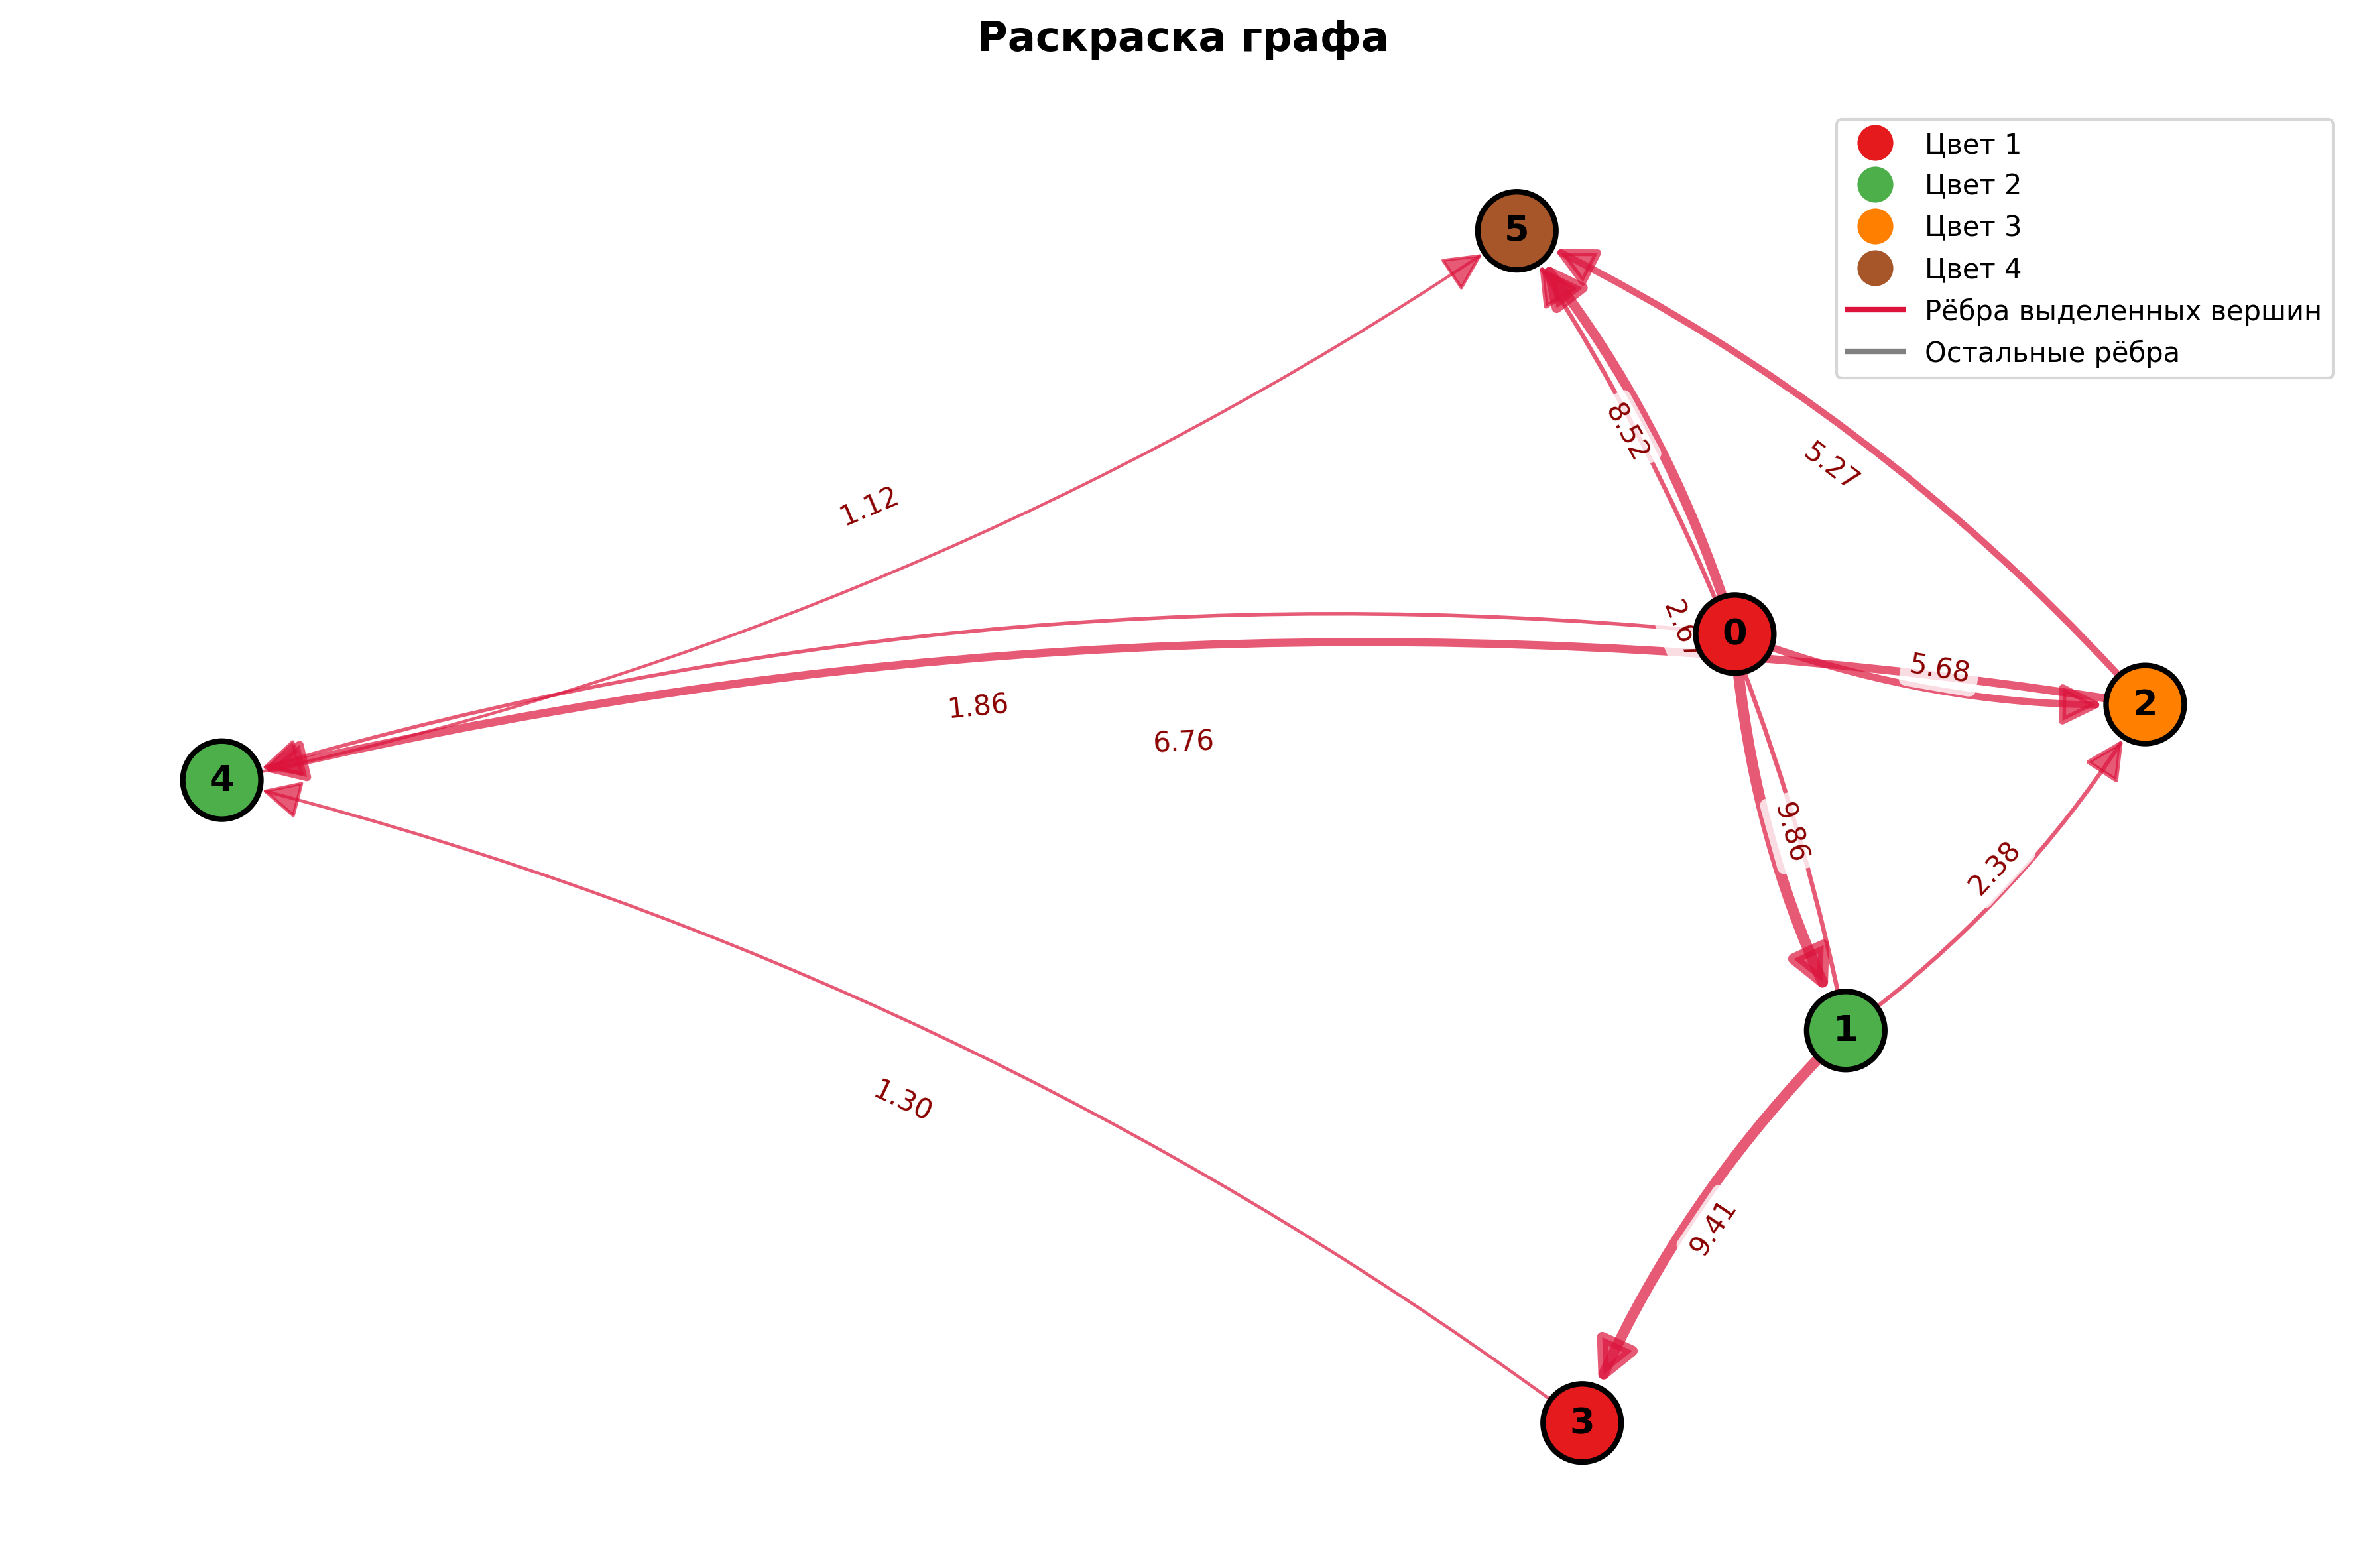

In [120]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/46_coloring.png')

## Lab 5: Циклы

Генерация неориентированного графа для проверки эйлеровости, гамильтоновости и решения задачи коммивояжера.

In [121]:
directed = 0
vertices = 6
edges = 11

run_cpp({
    '1' : f'0\n{vertices}\n{edges}\n',
    '51': '',
    '52': '',
    '53': '',
    '0': ''
})

True

## Проверка эйлеровости

In [122]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/51_euler_cycle.png')  # Может не генерироваться, если граф только полуэйлеров

Изображение не найдено: /Users/ivan/prog/poly/sem4/graph/assets/png/51_euler_cycle.png


## Проверка Гамильтоновости

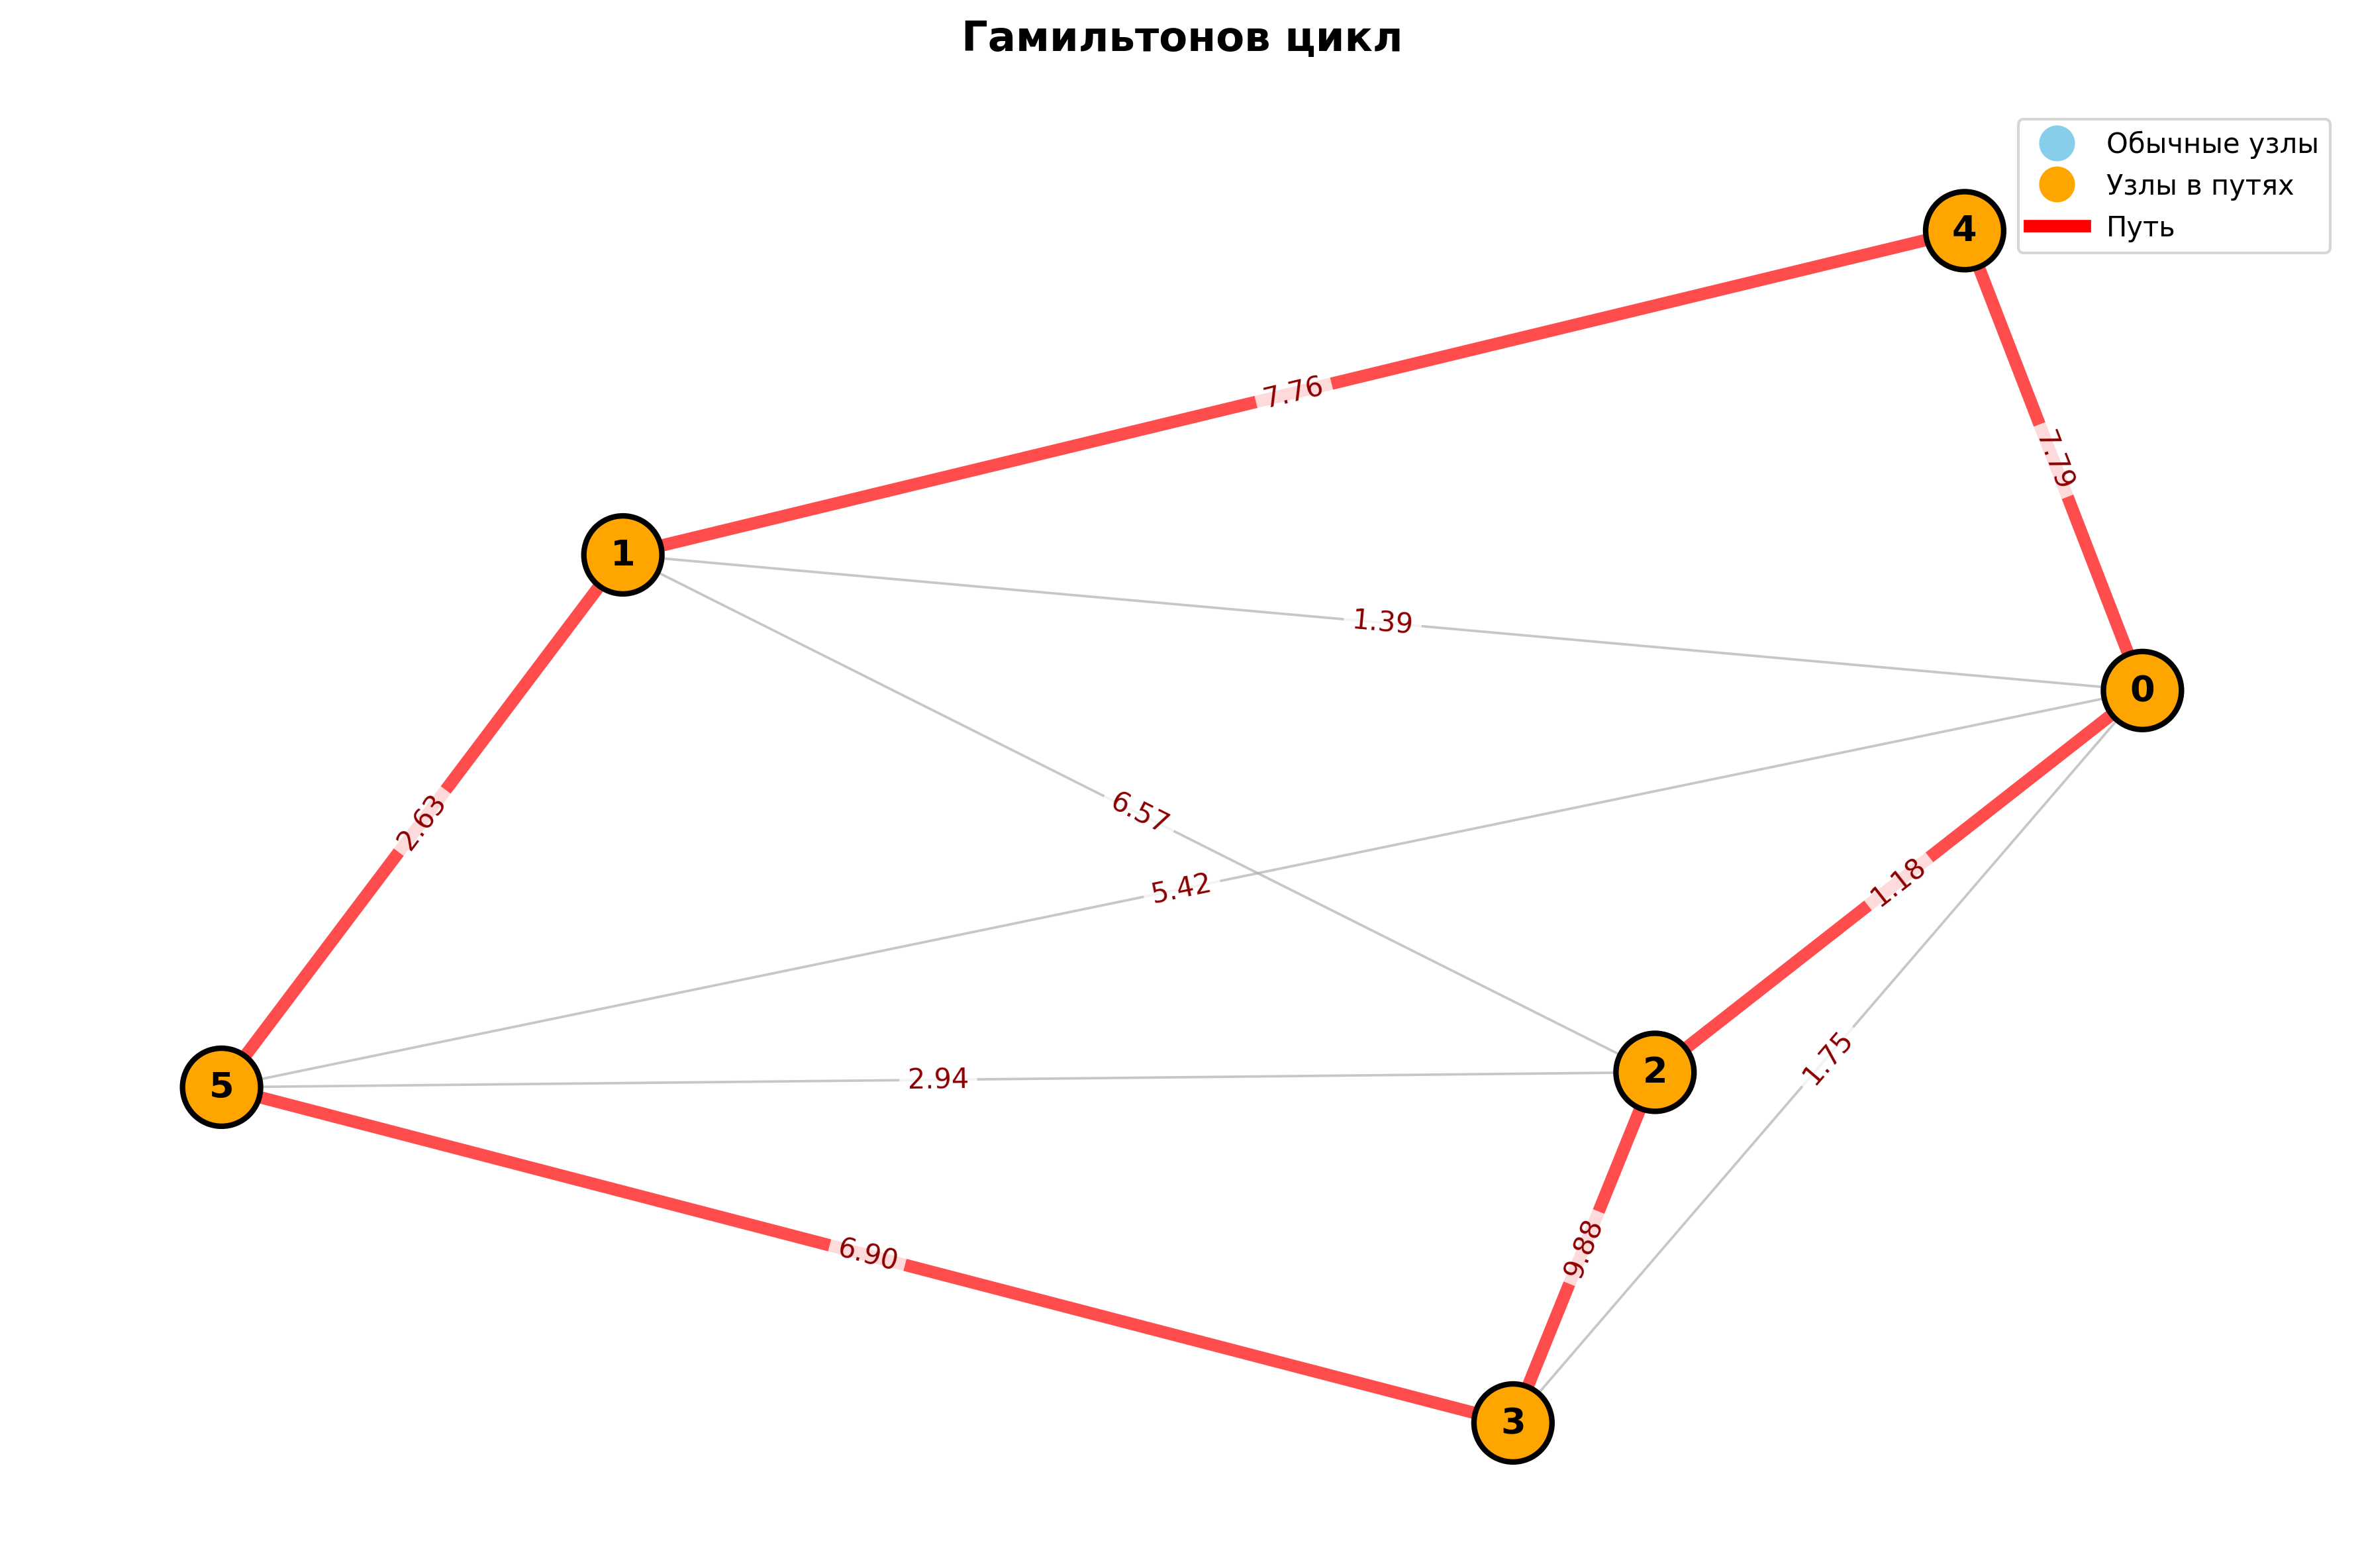

In [123]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/52_hamilton_cycle.png')

## Задача коммивояжера (TSP)

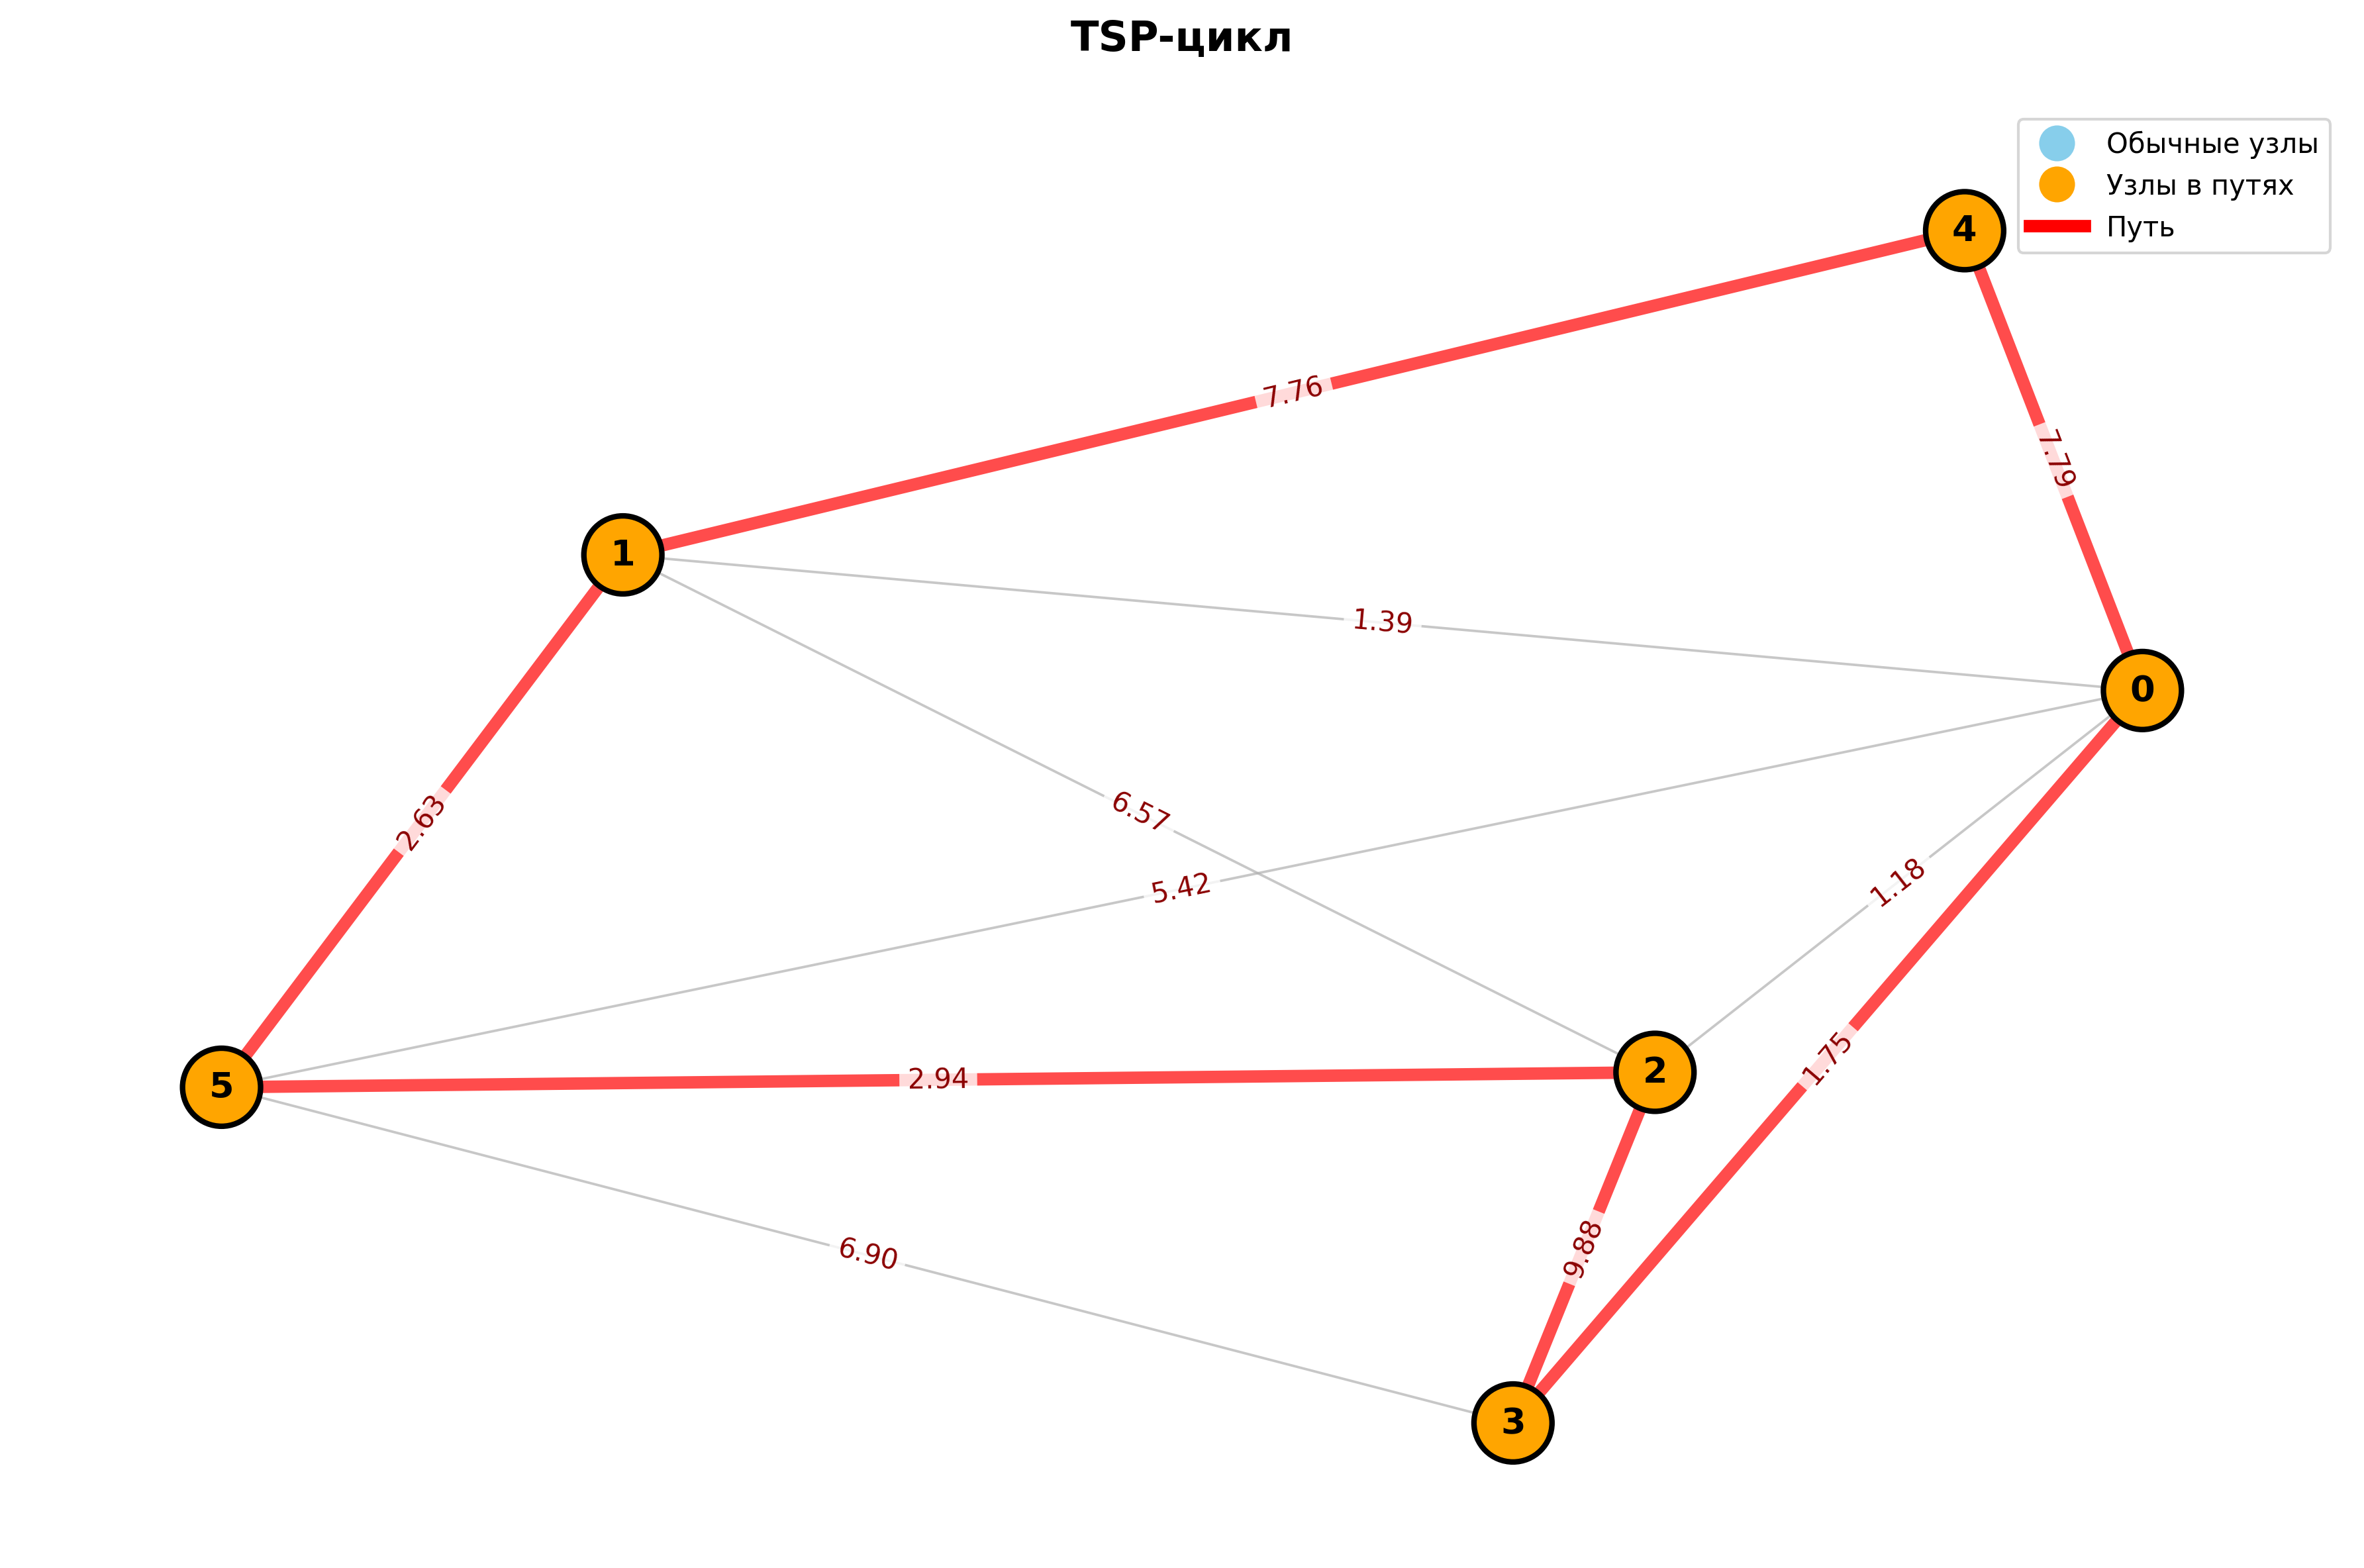

In [124]:
show_image('/Users/ivan/prog/poly/sem4/graph/assets/png/53_tsp_cycle.png')

## Очистка директории assets

Очистка всех сгенерированных файлов в директориях `assets/png/`, `assets/txt/` и `assets/gif/`.

In [125]:
import shutil

assets_dirs = [
    '/Users/ivan/prog/poly/sem4/graph/assets/png',
    '/Users/ivan/prog/poly/sem4/graph/assets/txt',
    '/Users/ivan/prog/poly/sem4/graph/assets/gif'
]

for dir_path in assets_dirs:
    if os.path.exists(dir_path):
        for file in os.listdir(dir_path):
            file_path = os.path.join(dir_path, file)
            if os.path.isfile(file_path):
                os.unlink(file_path)


print('\nОчистка завершена')


Очистка завершена
